# 01 — The data the pipeline consumes

This notebook looks at the **inputs**, not the results. One section per dataset, in the
order the pipeline meets them:

| section | dataset | who consumes it |
|---|---|---|
| **01** | the four TRIS archive products | stage 1 |
| **02** | ARCADE 2 at 3.15 and 3.41 GHz | nothing yet — a first look |
| **03** | Haslam 408 MHz | stage 2 |

`DATA_SOURCES.md` has the archive page, the config key and the consuming stage for each
of them. Stage 1's *results* are in `03_diagnostics.ipynb`; stage 2's are in
`02_build_berkhijsen_prior.ipynb`.

Note on where the files are: section 01 reads the TRIS text products through
`paths.tris_archive_dir`, which points at the limTOD checkout. Sections 02 and 03 read
the FITS maps in `res/`, which also holds a second copy of those same TRIS text files.

In [51]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"

import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from astropy.io import fits

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white",
                     "savefig.facecolor": "white", "axes.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import stage1_tris_maps as stage1

config = load_config(REPO / "configs" / "run_config.yaml")
tris = stage1.import_limtod_tris(config)
ARCHIVE = config.resolve_path("paths.tris_archive_dir")
RES = REPO / "res"          # the FITS maps sections 02 and 03 look at

# One palette for every sky map in this notebook, so panels from different
# sections can be compared by eye without the colour scheme moving underneath.
# Sequential = ONE hue, light -> dark.  Never a rainbow: a multi-hue ramp
# invents structure at its hue boundaries that is not in the data.
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95",
             "#104281"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
SEQ.set_bad("#e8e8e6")                 # unobserved sky: recessive, not black
# healpy paints the area OUTSIDE the projection with the colormap's "under"
# colour, not with bgcolor -- without this every map sits on a slab of the
# ramp's lightest tone instead of on the page.
SEQ.set_under("white")
MAP_KW = dict(cmap=SEQ, badcolor="#e8e8e6", bgcolor="white")

# Fixed categorical order, validated for colour-vision separation. Used where
# two grids are drawn as SERIES rather than as maps.
GRID_COLOUR = {8: "#2a78d6", 16: "#eb6834"}

print("config   ", config.path)
print("archive  ", ARCHIVE)
print("res      ", RES)
print("limTOD   ", Path(tris.__file__).resolve())
print()
print("stage 1 decisions in force:")
for key in ("tris.frequencies_mhz", "tris.ref_freq_mhz", "tris.mapmaker",
            "tris.nside", "tris.dec_half_width_deg", "tris.zero_level_sigma_k",
            "tris.prior.template", "tris.prior.relative_sigma",
            "tris.prior.absolute_sigma_k", "tris.solver.method", "tris.solver.rtol"):
    print(f"  {key:32s} {config.get_path(key)}")

config    /Users/user/Documents/Codes/project3/moonrunes/configs/run_config.yaml
archive   /Users/user/Documents/Codes/project3/limTOD/downloads/TRIS
res       /Users/user/Documents/Codes/project3/moonrunes/res
limTOD    /Users/user/Documents/Codes/project3/limTOD/limTOD/tris/__init__.py

stage 1 decisions in force:
  tris.frequencies_mhz             [600, 820]
  tris.ref_freq_mhz                600
  tris.mapmaker                    prior_regularized
  tris.nside                       8
  tris.dec_half_width_deg          45.0
  tris.zero_level_sigma_k          0.5
  tris.prior.template              gsm2008
  tris.prior.relative_sigma        0.1
  tris.prior.absolute_sigma_k      0.3
  tris.solver.method               gmres
  tris.solver.rtol                 1e-12


---
# 01 — The TRIS data that stage 1 consumes

The four archive products, the beam, the temperature convention, and the GSM2008 template
that stands in for a prior (Blocker 2).

This section also shows where three config decisions come from, so they are not just
numbers in a YAML file:

| config key | decided here |
|---|---|
| `tris.zero_level_sigma_k = 0.5` | the archive's own zero levels, one of which is asymmetric |
| `tris.uncertainty_floor_k = null` | each ring has exactly one row with a 0.000 K error |
| `beam.beam_deg` → `beam.nside_new = 8` | Blocker 1, checked against `bayesian_func.nside_for_beam` |

The convention translation itself (boresight at `RA=LST, dec=lat`, `selfrot=-7`,
Rayleigh–Jeans including the CMB monopole) is **verified numerically** in limTOD's own
walkthrough, `examples/TRIS/tris_limtod_walkthrough.ipynb`. Nothing here re-derives it;
this section checks that the pipeline is holding it correctly.

## The four products

Two absolutely-calibrated drift rings (600 and 820 MHz), one point set (2.5 GHz, dropped
— it is not a ring, and the literature review flags its quality), and the beam profile.

In [52]:
ring600 = tris.read_tris_ring(ARCHIVE / "TRIS_absolute_600.txt")
ring820 = tris.read_tris_ring(ARCHIVE / "TRIS_absolute_820.txt")
points  = tris.read_tris_point_set(ARCHIVE / "TRIS_absolute_2500MHz.txt")
cuts    = tris.read_tris_beam_cuts(ARCHIVE / "TRIS_Beam_Profile.txt")
RINGS   = {600: ring600, 820: ring820}

print(f"{'product':18s}{'n':>5}{'nu_eff [MHz]':>14}{'T range [K]':>22}")
for name, obj in (("600 MHz ring", ring600), ("820 MHz ring", ring820),
                  ("2.5 GHz points", points)):
    print(f"{name:18s}{obj.ra_deg.size:5d}{obj.effective_frequency_mhz:14.1f}"
          f"{f'{obj.temperature_k.min():.3f} .. {obj.temperature_k.max():.3f}':>22}")
print(f"{'beam cuts':18s}{cuts.angle_deg.size:5d}"
      f"{'':>14}{f'0 .. {cuts.angle_deg.max():.0f} deg':>22}")

print("\nTwo details a careless reader would destroy:")
print("  RA spacings present:", sorted(set(np.round(np.diff(ring600.ra_deg), 9))),
      "deg  <- NOT a uniform 3 deg grid")
print("  rows with a 0.000 K statistical error:",
      int((ring600.statistical_uncertainty_k == 0).sum()), "(600) and",
      int((ring820.statistical_uncertainty_k == 0).sum()), "(820)")
print("  -> tris.uncertainty_floor_k = null means stage 1 uses each ring's smallest")
print("     strictly positive error instead:",
      {f: float(r.statistical_uncertainty_k[r.statistical_uncertainty_k > 0].min())
       for f, r in RINGS.items()}, "K")

product               n  nu_eff [MHz]           T range [K]
600 MHz ring        120         600.5       9.390 .. 28.193
820 MHz ring        120         817.8       5.357 .. 13.574
2.5 GHz points        6        2427.8        2.329 .. 2.886
beam cuts            55                        0 .. 176 deg

Two details a careless reader would destroy:
  RA spacings present: [np.float64(2.75), np.float64(3.0), np.float64(3.25)] deg  <- NOT a uniform 3 deg grid
  rows with a 0.000 K statistical error: 1 (600) and 1 (820)
  -> tris.uncertainty_floor_k = null means stage 1 uses each ring's smallest
     strictly positive error instead: {600: 0.004, 820: 0.004} K


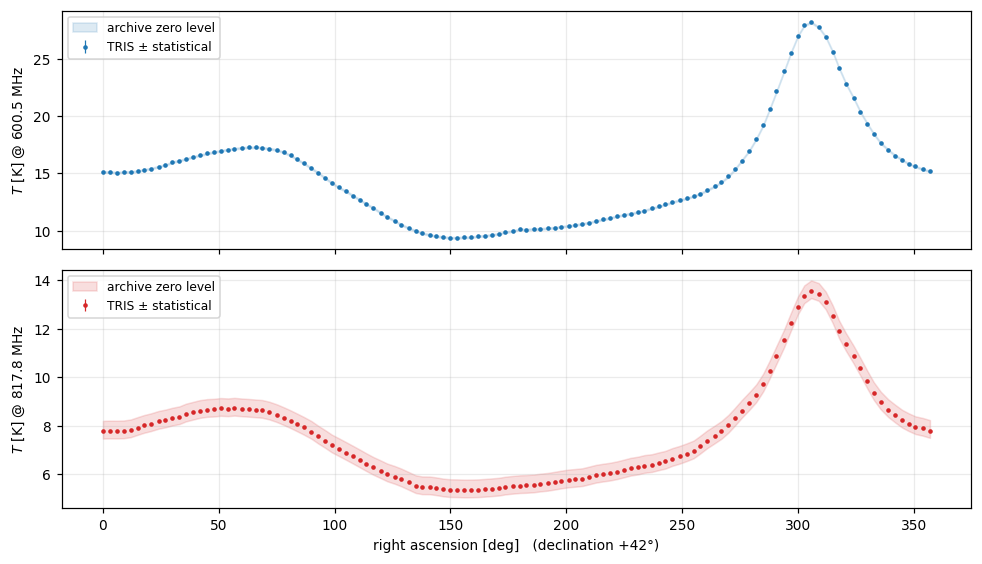

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True)
for ax, (freq, ring), colour in zip(axes, RINGS.items(), ("tab:blue", "tab:red")):
    ax.errorbar(ring.ra_deg, ring.temperature_k, yerr=ring.statistical_uncertainty_k,
                fmt=".", ms=4, lw=0.8, color=colour, label="TRIS ± statistical")
    zero = ring.zero_level_uncertainty_k
    lo, hi = (zero, zero) if np.isscalar(zero) else (zero.negative_k, zero.positive_k)
    ax.fill_between(ring.ra_deg, ring.temperature_k - lo, ring.temperature_k + hi,
                    color=colour, alpha=0.15, label="archive zero level")
    ax.set_ylabel(f"$T$ [K] @ {ring.effective_frequency_mhz:.1f} MHz")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.25)
axes[1].set_xlabel("right ascension [deg]   (declination +42°)")
# axes[0].set_title("The absolute rings stage 1 fits — the zero level dwarfs the "
                #   "statistical errors")
fig.tight_layout()

### Where `tris.zero_level_sigma_k = 0.5` comes from

The published zero level is one fully correlated offset. Stage 1 carries it as an
explicit nuisance parameter with a Gaussian prior — exactly equivalent to the rank-1
noise term, but it also hands back the fitted offset.

The catch is that the 820 MHz zero level is **asymmetric**, and limTOD deliberately
refuses to symmetrise it for you. A single Gaussian width has to cover both rings without
claiming a precision the 820 MHz ring does not have.

In [54]:
chosen = float(config.require("tris.zero_level_sigma_k"))
print(f"{'ring':>6}  {'archive zero level':<34}{'covered by 0.5 K?':>18}")
for freq, ring in RINGS.items():
    z = ring.zero_level_uncertainty_k
    text = (f"{float(z):.3f} K (symmetric)" if np.isscalar(z)
            else f"+{z.positive_k:.3f} / -{z.negative_k:.3f} K (ASYMMETRIC)")
    widest = float(z) if np.isscalar(z) else max(z.positive_k, z.negative_k)
    print(f"{freq:6d}  {text:<34}{'yes' if chosen >= widest else 'NO':>18}")
print(f"\ntris.zero_level_sigma_k = {chosen} K: one symmetric prior wide enough for both,")
print("recorded as a decision rather than silently symmetrising +0.430/-0.300.")

  ring  archive zero level                 covered by 0.5 K?
   600  0.066 K (symmetric)                              yes
   820  +0.430 / -0.300 K (ASYMMETRIC)                   yes

tris.zero_level_sigma_k = 0.5 K: one symmetric prior wide enough for both,
recorded as a decision rather than silently symmetrising +0.430/-0.300.


---
## The temperature convention

The archive never states Rayleigh–Jeans vs thermodynamic, nor whether the CMB monopole is
included. The two rings share an RA grid, so the Galactic spectral index between them is a
clean per-sample discriminator: only one treatment gives synchrotron. Stage 1's template
is built with `to_tris_temperature_convention`, so this has to come out right or every
kelvin downstream is wrong.

CMB monopole: thermodynamic 2.72548 K, RJ-equivalent 2.7111 K at 600.5 MHz
treatment                        min   median     max
CMB monopole left in           -2.39    -2.10   -1.81
CMB monopole removed (RJ)      -3.12    -2.91   -2.63

Synchrotron is -2.5..-3.1. Only the second row is physical, so TRIS
temperatures are Rayleigh-Jeans and INCLUDE the CMB monopole.


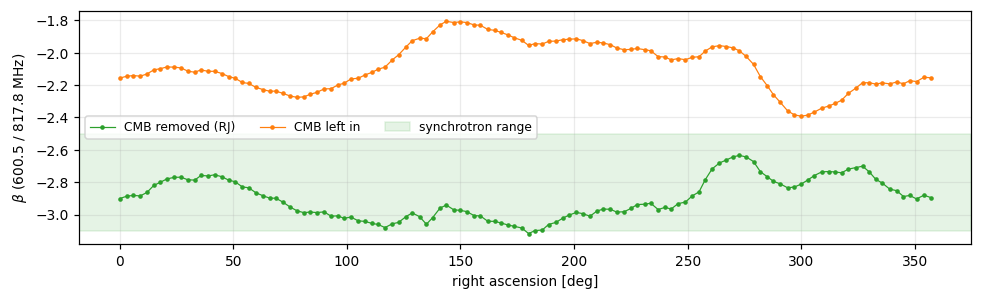

In [55]:
nu6, nu8 = ring600.effective_frequency_mhz, ring820.effective_frequency_mhz
assert np.allclose(ring600.ra_deg, ring820.ra_deg)

with_cmb = np.log(ring600.temperature_k / ring820.temperature_k) / np.log(nu6 / nu8)
without = tris.galactic_spectral_index(ring600.temperature_k, nu6,
                                       ring820.temperature_k, nu8)

print(f"CMB monopole: thermodynamic {tris.CMB_T0_K:.5f} K, "
      f"RJ-equivalent {tris.cmb_monopole_rj_k(nu6):.4f} K at {nu6} MHz")
print(f"{'treatment':<28}{'min':>8}{'median':>9}{'max':>8}")
print(f"{'CMB monopole left in':<28}{with_cmb.min():8.2f}{np.median(with_cmb):9.2f}"
      f"{with_cmb.max():8.2f}")
print(f"{'CMB monopole removed (RJ)':<28}{without.min():8.2f}{np.median(without):9.2f}"
      f"{without.max():8.2f}")
print("\nSynchrotron is -2.5..-3.1. Only the second row is physical, so TRIS")
print("temperatures are Rayleigh-Jeans and INCLUDE the CMB monopole.")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(ring600.ra_deg, without, ".-", ms=4, lw=0.8, color="tab:green",
        label="CMB removed (RJ)")
ax.plot(ring600.ra_deg, with_cmb, ".-", ms=4, lw=0.8, color="tab:orange",
        label="CMB left in")
ax.axhspan(-3.1, -2.5, color="tab:green", alpha=0.12, label="synchrotron range")
ax.set_xlabel("right ascension [deg]")
ax.set_ylabel(r"$\beta$ (600.5 / 817.8 MHz)")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.25)
fig.tight_layout()

---
## The beam, and Blocker 1

Stage 1 builds the beam from the archive's own principal-plane cuts, never a Gaussian:
the cuts run to 176° and −49 dB, and the Gaussian has no shoulders at all. The
below-horizon response is small but not negligible against the published 0.066 K
systematic, which is why the horizon mask is on.

Blocker 1 is the separate question of what beam width `bayesian_skymap` is told about
downstream. `beam.beam_deg` is the mean of the two principal planes (its forward model is
azimuthally symmetric, so an asymmetric beam cannot be represented), and the cell below
runs the fork's own heuristic to confirm the pinned `beam.nside_new`.

archive table HPBW: E 19.155 deg, H 23.366 deg  (the ring header's '18 deg' is -6.0% off)

Blocker 1 — beam.beam_deg = 21.2605 deg (mean of E and H = 21.2603)
  bayesian_func.nside_for_beam -> 8, config pins 8  -> consistent


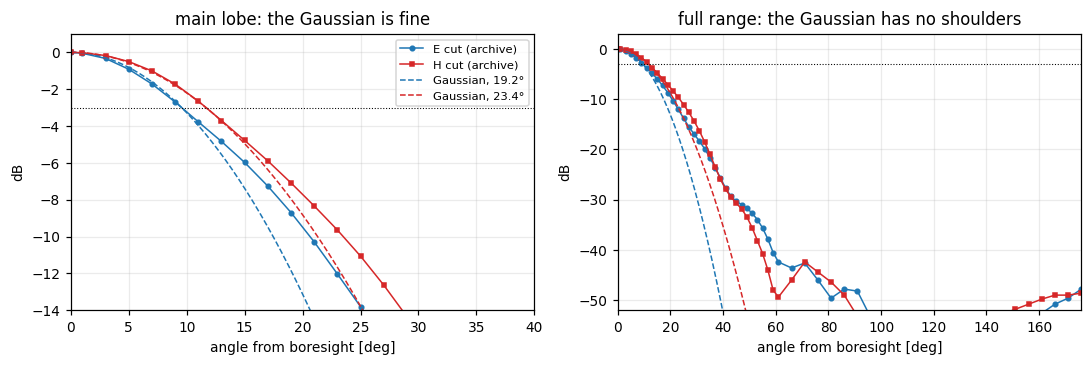

In [56]:
e_fwhm, h_fwhm = cuts.half_power_full_width_deg()
half_power_db = -10 * np.log10(2)
print(f"archive table HPBW: E {e_fwhm:.3f} deg, H {h_fwhm:.3f} deg  "
      f"(the ring header's '18 deg' is {100*(18/e_fwhm-1):+.1f}% off)")

check = stage1._check_beam_against_bayesian_skymap(config)
print(f"\nBlocker 1 — beam.beam_deg = {check['beam_deg']:.4f} deg "
      f"(mean of E and H = {(e_fwhm+h_fwhm)/2:.4f})")
print(f"  bayesian_func.nside_for_beam -> {check['nside_new_from_bayesian_func']}, "
      f"config pins {check['nside_new_pinned']}  -> consistent")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
fine = np.linspace(0, 60, 400)
for ax, span in zip(axes, [(0, 40, -14, 1), (0, 176, -52, 3)]):
    ax.plot(cuts.angle_deg, cuts.e_plane_db, "o-", ms=3, lw=1, color="tab:blue",
            label="E cut (archive)")
    ax.plot(cuts.angle_deg, cuts.h_plane_db, "s-", ms=3, lw=1, color="tab:red",
            label="H cut (archive)")
    ax.plot(fine, half_power_db * (2 * fine / e_fwhm) ** 2, "--", color="tab:blue",
            lw=1, label=f"Gaussian, {e_fwhm:.1f}°")
    ax.plot(fine, half_power_db * (2 * fine / h_fwhm) ** 2, "--", color="tab:red",
            lw=1, label=f"Gaussian, {h_fwhm:.1f}°")
    ax.axhline(half_power_db, color="k", lw=0.7, ls=":")
    ax.set_xlim(span[0], span[1]); ax.set_ylim(span[2], span[3])
    ax.set_xlabel("angle from boresight [deg]"); ax.set_ylabel("dB")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=7.5)
axes[0].set_title("main lobe: the Gaussian is fine")
axes[1].set_title("full range: the Gaussian has no shoulders")
fig.tight_layout()

In [57]:
NSIDE_BEAM = 128
cut_beam = tris.tris_cut_beam_map(cuts, nside=NSIDE_BEAM, normalization="peak")
gauss_beam = tris.approximate_tris_gaussian_beam_map(nside=NSIDE_BEAM,
                                                     normalization="peak")
theta = np.rad2deg(hp.pix2ang(NSIDE_BEAM, np.arange(hp.nside2npix(NSIDE_BEAM)))[0])
order = np.argsort(theta)
mask = tris.tris_horizon_mask(NSIDE_BEAM)

print(f"{'beam':<16}{'θ<10°':>9}{'θ<20°':>9}{'θ<30°':>9}{'θ<45°':>9}"
      f"{'below horizon':>16}{'ground @300K':>14}")
for name, beam in (("Gaussian", gauss_beam), ("archive cuts", cut_beam)):
    weight = beam / beam.sum()
    cumulative = np.cumsum(weight[order])
    below = float(weight[mask == 0].sum())
    cums = [cumulative[theta[order] < lim][-1] for lim in (10, 20, 30, 45)]
    print(f"{name:<16}" + "".join(f"{c:9.4f}" for c in cums)
          + f"{below:16.2e}{below*300:14.3f} K")
print("\nbeam.apply_horizon_mask =", config.require("beam.apply_horizon_mask"),
      "-- the cut beam's ground pickup is comparable to the 0.066 K systematic.")

beam                θ<10°    θ<20°    θ<30°    θ<45°   below horizon  ground @300K
Gaussian           0.4917   0.9260   0.9965   1.0000        2.77e-20         0.000 K
archive cuts       0.3809   0.8107   0.9660   0.9970        1.16e-04         0.035 K

beam.apply_horizon_mask = True -- the cut beam's ground pickup is comparable to the 0.066 K systematic.


---
## The prior template (Blocker 2's substitute)

There is no true sky for real data, and Berkhuijsen (1972) is not in hand yet, so
**GSM2008 is used as both the prior template and the reference "truth"**. That is
circular by construction and stage 1's manifest records it as such.

What makes it still worth doing is the number below. Forward-modelling GSM2008 through
the same geometry and beam that stage 1 uses gives a *measured* offset against the
absolutely-calibrated rings — and stage 1's fitted zero level should come out at
roughly that value, because a tight per-pixel prior leaves the nuisance offset as the
only place a template error can go. That correspondence is the real check on stage 1,
and `03_diagnostics.ipynb` makes it.

In [58]:
from limTOD import generate_TOD_sky

NSIDE_SKY = int(config.require("tris.nside"))
horizon = tris.tris_horizon_mask(NSIDE_SKY)
beam_sky = tris.tris_cut_beam_map(cuts, nside=NSIDE_SKY, normalization="peak")

templates, profiles, offsets = {}, {}, {}
for freq, ring in RINGS.items():
    nu = ring.effective_frequency_mhz
    templates[freq] = stage1.gsm2008_template(nu, NSIDE_SKY)   # the stage 1 template
    g = tris.tris_zenith_geometry(ring.ra_deg)
    profiles[freq] = generate_TOD_sky(beam_sky, templates[freq], g.lst_deg,
                                      g.latitude_deg, g.azimuth_deg, g.elevation_deg,
                                      g.selfrot_deg, normalize_beam=True,
                                      horizontal_mask=horizon)
    offsets[freq] = profiles[freq] - ring.temperature_k

print(f"{'nu [MHz]':>9}{'mean GSM2008 - TRIS':>22}{'scatter rms':>13}{'max |Δ|':>10}")
for freq, d in offsets.items():
    print(f"{freq:9d}{d.mean():+22.3f}{d.std():13.3f}{np.abs(d).max():10.3f}")
print("\nGSM2008 runs COLD against the absolute rings. Stage 1's fitted zero level")
print("should land near the negative of these means:",
      {f: round(-float(d.mean()), 2) for f, d in offsets.items()}, "K")

 nu [MHz]   mean GSM2008 - TRIS  scatter rms   max |Δ|
      600                -1.956        0.769     5.300
      820                -0.580        0.374     2.038

GSM2008 runs COLD against the absolute rings. Stage 1's fitted zero level
should land near the negative of these means: {600: 1.96, 820: 0.58} K


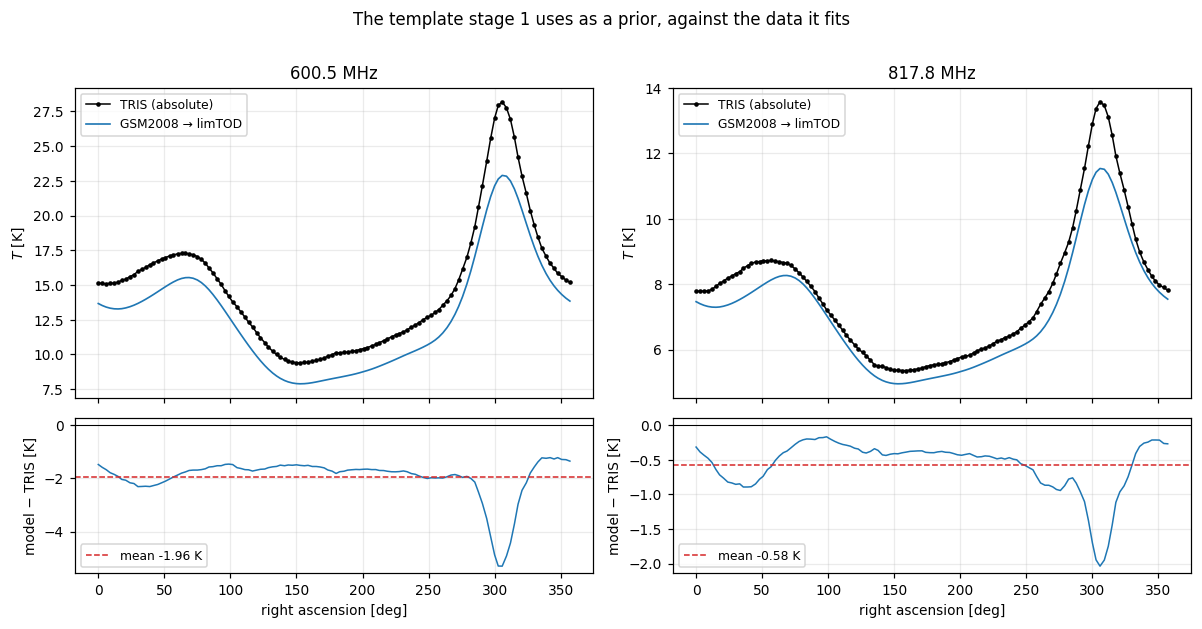

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.6), sharex="col",
                         gridspec_kw={"height_ratios": [2, 1]})
for col, (freq, ring) in enumerate(RINGS.items()):
    top, bot = axes[0, col], axes[1, col]
    top.plot(ring.ra_deg, ring.temperature_k, "k.-", ms=4, lw=1.0,
             label="TRIS (absolute)")
    top.plot(ring.ra_deg, profiles[freq], lw=1.1, color="tab:blue",
             label="GSM2008 → limTOD")
    bot.plot(ring.ra_deg, offsets[freq], lw=1.0, color="tab:blue")
    bot.axhline(0, color="k", lw=0.7)
    bot.axhline(offsets[freq].mean(), color="tab:red", ls="--", lw=1,
                label=f"mean {offsets[freq].mean():+.2f} K")
    top.set_ylabel("$T$ [K]"); bot.set_ylabel("model − TRIS [K]")
    bot.set_xlabel("right ascension [deg]")
    top.set_title(f"{ring.effective_frequency_mhz:.1f} MHz")
    top.legend(fontsize=8); bot.legend(fontsize=8)
    top.grid(alpha=0.25); bot.grid(alpha=0.25)
fig.suptitle("The template stage 1 uses as a prior, against the data it fits", y=1.01)
fig.tight_layout()

---
## Pixelisation: what 120 samples can and cannot support

The beam is 19.2° × 23.4°, and a 120-sample ring measures roughly 15 independent numbers
because the beam suppresses harmonics above $m\sim8$. The table below is the honest
accounting of what each candidate `tris.nside` asks for.

`tris.nside` is the grid stage 1 *solves* on; `beam.nside_new` is the grid stage 3 hands
to `bayesian_skymap`. They do not have to match — stage 3 degrades — but the ratio of
pixels to samples is what decides how much of the answer is prior rather than data.

In [60]:
working = int(config.require("tris.nside"))
target = int(config.require("beam.nside_new"))
half_width = float(config.require("tris.dec_half_width_deg"))
dec = tris.tris_zenith_geometry(ring600.ra_deg).boresight_dec_deg
n_samples = ring600.ra_deg.size

print(f"{'nside':>7}{'pixel [deg]':>13}{'E FWHM/pix':>12}{'H FWHM/pix':>12}"
      f"{'pixels in band':>16}{'samples/pixel':>15}   note")
for nside in (4, 8, 16, 32, 64):
    pixel_deg = hp.nside2resol(nside, arcmin=True) / 60
    n_band = tris.tris_ring_pixels(nside, dec_deg=dec,
                                   half_width_deg=half_width).size
    note = []
    if nside == working:
        note.append("tris.nside (stage 1 solves here)")
    if nside == target:
        note.append("beam.nside_new (stage 3 target)")
    print(f"{nside:7d}{pixel_deg:13.2f}{e_fwhm/pixel_deg:12.2f}{h_fwhm/pixel_deg:12.2f}"
          f"{n_band:16d}{n_samples/n_band:15.4f}   {', '.join(note)}")
print(f"\nThe ring has {n_samples} samples and about 15 independent numbers in them.")
print("At every nside in this table the pixels outnumber the data, so the map is")
print("prior-dominated by construction -- 03_diagnostics.ipynb measures by how much.")

  nside  pixel [deg]  E FWHM/pix  H FWHM/pix  pixels in band  samples/pixel   note
      4        14.66        1.31        1.59             104         1.1538   
      8         7.33        2.61        3.19             400         0.3000   tris.nside (stage 1 solves here), beam.nside_new (stage 3 target)
     16         3.66        5.23        6.38            1632         0.0735   
     32         1.83       10.45       12.75            6460         0.0186   
     64         0.92       20.91       25.51           25704         0.0047   

The ring has 120 samples and about 15 independent numbers in them.
At every nside in this table the pixels outnumber the data, so the map is
prior-dominated by construction -- 03_diagnostics.ipynb measures by how much.


---
# 02 — ARCADE 2

ARCADE 2 is a balloon-borne, absolutely calibrated radiometer, and in the SED design
(`tris_haslam_pipeline.md`) its two lowest bands are trusted points **3 and 4**. That is
the whole reason it is here: TRIS alone gives two bands, and a two-parameter power law
through two points is exactly determined — zero residual, no way to test the power law
itself. ARCADE 2 makes the per-pixel fit over-determined and gives it a χ² worth reading.

So this section is not idle exploration; it is the check on whether these files can carry
that weight. Two properties decide it, and the design document depends on both: the
pixelisation the maps arrive on, and how they mark the sky they never observed.

## 3.15 GHz

In [61]:
with fits.open(RES / "ARCADE2_315.fits") as hdul:
    hdul.info()
    print(hdul[1].header)   # HEALPix maps store data in a binary table, usually HDU 1

Filename: /Users/user/Documents/Codes/project3/moonrunes/res/ARCADE2_315.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1  Archive Map Table    1 BinTableHDU     31   3072R x 2C   [E, E]   


XTENSION= 'BINTABLE'           /binary table extension                          BITPIX  =                    8 /8-bit bytes                                     NAXIS   =                    2 /2-dimensional binary table                      NAXIS1  =                    8 /width of table in bytes                         NAXIS2  =                 3072 /number of rows in table                         PCOUNT  =                    0 /size of special data area                       GCOUNT  =                    1 /one data group (required keyword)               TFIELDS =                    2 /number of fields in each row                    COMMENT                                                                         COMMENT  *** End of mandatory fields ***                                        COMMENT                                                                         COMMENT                                                                         COMMENT  *** Column names ***           

nside: 16
npix:  3072


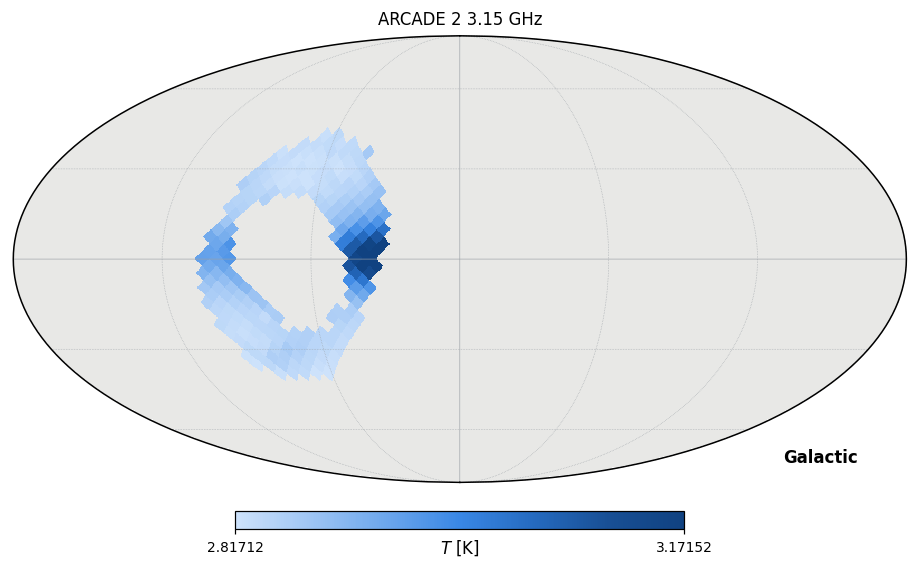

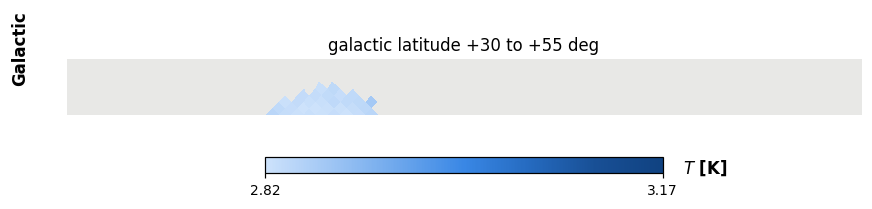

In [62]:
arcade315 = hp.read_map(RES / "ARCADE2_315.fits")
# Check these explicitly before doing anything else -- they matter:
print("nside:", hp.get_nside(arcade315))
print("npix: ", hp.get_map_size(arcade315))

# Percentile limits, matching every other map in this notebook.
# NOTE: ~93% of these pixels are exact zero (unobserved sky stored as
# data), so they sit at the bottom of the ramp and compress the real
# range. Section 02 measures that; this is only how it looks.
lo_a, hi_a = np.percentile(arcade315[arcade315 != 0], [2, 98])

# Unobserved sky is stored as exact 0.0 in these files. Plot it as NaN so it
# renders like TRIS's unobserved sky rather than as a very cold measurement --
# the array itself is untouched, this is display only.
arcade315_shown = np.where(arcade315 == 0, np.nan, arcade315)

hp.mollview(arcade315_shown, title="ARCADE 2 3.15 GHz", unit="$T$ [K]", coord="G", min=lo_a, max=hi_a, **MAP_KW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
# latra is GALACTIC latitude here, not TRIS's equatorial dec +42 band.
hp.cartview(arcade315_shown, latra=[30, 55], unit="$T$ [K]",
            title="galactic latitude +30 to +55 deg", coord="G", min=lo_a, max=hi_a, **MAP_KW)
plt.show()

## 3.41 GHz

In [63]:
with fits.open(RES / "ARCADE2_341.fits") as hdul:
    hdul.info()
    print(hdul[1].header)   # HEALPix maps store data in a binary table, usually HDU 1

Filename: /Users/user/Documents/Codes/project3/moonrunes/res/ARCADE2_341.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1  Archive Map Table    1 BinTableHDU     31   3072R x 2C   [E, E]   
XTENSION= 'BINTABLE'           /binary table extension                          BITPIX  =                    8 /8-bit bytes                                     NAXIS   =                    2 /2-dimensional binary table                      NAXIS1  =                    8 /width of table in bytes                         NAXIS2  =                 3072 /number of rows in table                         PCOUNT  =                    0 /size of special data area                       GCOUNT  =                    1 /one data group (required keyword)               TFIELDS =                    2 /number of fields in each row                    COMMENT                                                                         COMMENT  *** End 

nside: 16
npix:  3072


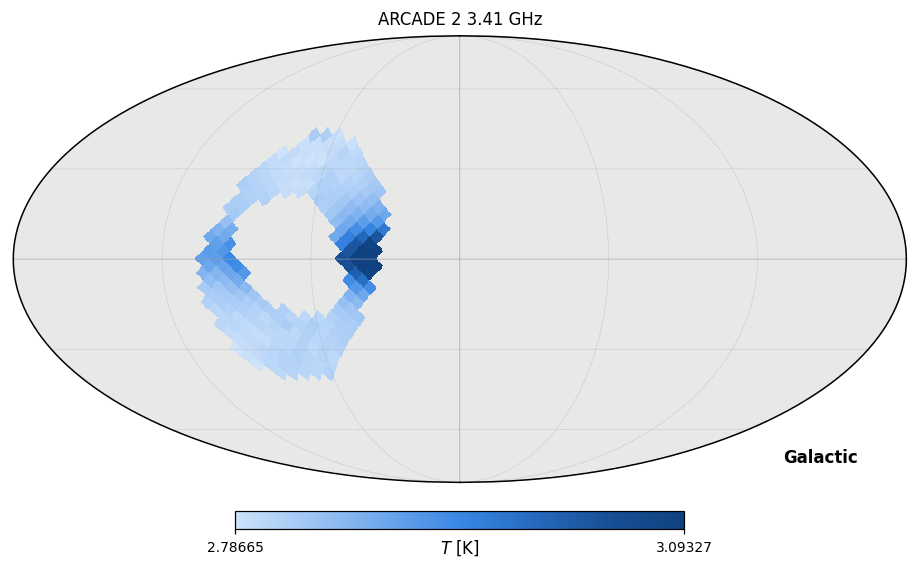

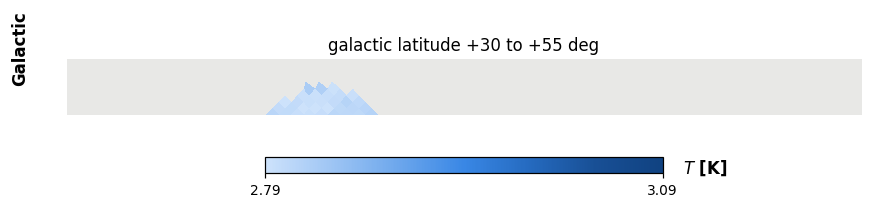

In [64]:
arcade341 = hp.read_map(RES / "ARCADE2_341.fits")
# Check these explicitly before doing anything else -- they matter:
print("nside:", hp.get_nside(arcade341))
print("npix: ", hp.get_map_size(arcade341))

# Percentile limits, matching every other map in this notebook.
# NOTE: ~93% of these pixels are exact zero (unobserved sky stored as
# data), so they sit at the bottom of the ramp and compress the real
# range. Section 02 measures that; this is only how it looks.
lo_a, hi_a = np.percentile(arcade341[arcade341 != 0], [2, 98])

# Unobserved sky is stored as exact 0.0 in these files. Plot it as NaN so it
# renders like TRIS's unobserved sky rather than as a very cold measurement --
# the array itself is untouched, this is display only.
arcade341_shown = np.where(arcade341 == 0, np.nan, arcade341)

hp.mollview(arcade341_shown, title="ARCADE 2 3.41 GHz", unit="$T$ [K]", coord="G", min=lo_a, max=hi_a, **MAP_KW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
# latra is GALACTIC latitude here, not TRIS's equatorial dec +42 band.
hp.cartview(arcade341_shown, latra=[30, 55], unit="$T$ [K]",
            title="galactic latitude +30 to +55 deg", coord="G", min=lo_a, max=hi_a, **MAP_KW)
plt.show()

## Are the unobserved pixels marked, or just zero?

`hp.UNSEEN` is the HEALPix sentinel for "no data here". If a partial-sky map does not use
it, an unobserved pixel is indistinguishable from a genuinely cold one, and every mean,
ratio or fit taken over the map is silently wrong.

This matters directly for Step 0 of the SED pipeline, which has to smooth ARCADE 2 down
to the TRIS beam: `hp.smoothing` works through a global spherical harmonic transform and
knows nothing about masks, so whatever these pixels contain gets spread across the mask
boundary into the data.

In [65]:
for label, m in (("3.15 GHz", arcade315), ("3.41 GHz", arcade341)):
    npix = m.size
    zero_marked = int(np.sum(m == 0))
    print(f"ARCADE 2 {label} map")
    print("  Any UNSEEN?", np.any(m == hp.UNSEEN))
    print("  Any NaN?   ", np.any(np.isnan(m)))
    print(f"  Exact zeros (suspicious if widespread): {zero_marked}/{npix}"
          f" = {zero_marked / npix * 100:.1f}% of pixels")
    print()

ARCADE 2 3.15 GHz map
  Any UNSEEN? False
  Any NaN?    False
  Exact zeros (suspicious if widespread): 2852/3072 = 92.8% of pixels

ARCADE 2 3.41 GHz map
  Any UNSEEN? False
  Any NaN?    False
  Exact zeros (suspicious if widespread): 2840/3072 = 92.4% of pixels



Neither sentinel is present and most of the sky is exact zero, so **the unobserved pixels
are plain zeros**: the mask has to be reconstructed from the zeros before anything else
happens to these maps. Step 0.3 of `tris_haslam_pipeline.md` is written against exactly
this — zero the masked pixels, smooth a binary weight map with the same kernel, divide,
then re-mask where the smoothed weight drops too low.

Two more things the header and the plots settle:

* the maps arrive **`NESTED` at nside 16** — `hp.read_map` reorders to `RING` on the way
  in, which is why the plots come out right without anything being said about it. Note
  how coarse that is: nside 16 is a 3.7° pixel, against Haslam's nside 512;
* the header carries **no `COORDSYS`**, so the `coord="G"` passed to the plotting calls
  is an assumption made here, not something the file states. The open coordinate-system
  TODO in the design document asks for exactly this to be confirmed, and the header does
  not confirm it.

The `cartview` panels are cut on **galactic** latitude, so they are not TRIS's
declination strip despite what an earlier version of this notebook called them — TRIS's
dec +42° band is equatorial and would need a frame conversion to appear here.

---
# 03 — Haslam 408 MHz

The map the whole pipeline exists to calibrate: the one untrusted point in the SED, at
408 MHz, against which the power law fitted to the four trusted TRIS and ARCADE 2 points
is evaluated.

This is the copy downloaded into `res/`. It is not what stage 2 reads — `paths.haslam_map`
is `null`, which means stage 2 takes the destriped/desourced Remazeilles (2015) map from
the astropy cache `pygdsm` populates. So treat this section as a look at the archive
product, not as a check on what stage 2 loaded.

In [66]:
with fits.open(RES / "HASLAM.fits") as hdul:
    hdul.info()
    print(hdul[1].header)   # HEALPix maps store data in a binary table, usually HDU 1

Filename: /Users/user/Documents/Codes/project3/moonrunes/res/HASLAM.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1                1 BinTableHDU     42   3072R x 1C   [1024E]   
XTENSION= 'BINTABLE'           /Written by IDL:  Mon Nov 17 15:46:41 2014       BITPIX  =                    8 /                                                NAXIS   =                    2 /Binary table                                    NAXIS1  =                 4096 /Number of bytes per row                         NAXIS2  =                 3072 /Number of rows                                  PCOUNT  =                    0 /Random parameter count                          GCOUNT  =                    1 /Group count                                     TFIELDS =                    1 /Number of columns                               TFORM1  = '1024E   '           /Real*4 (floating point)                         TTYPE1  = 'TEMPERATURE '    

nside: 512
npix:  3145728


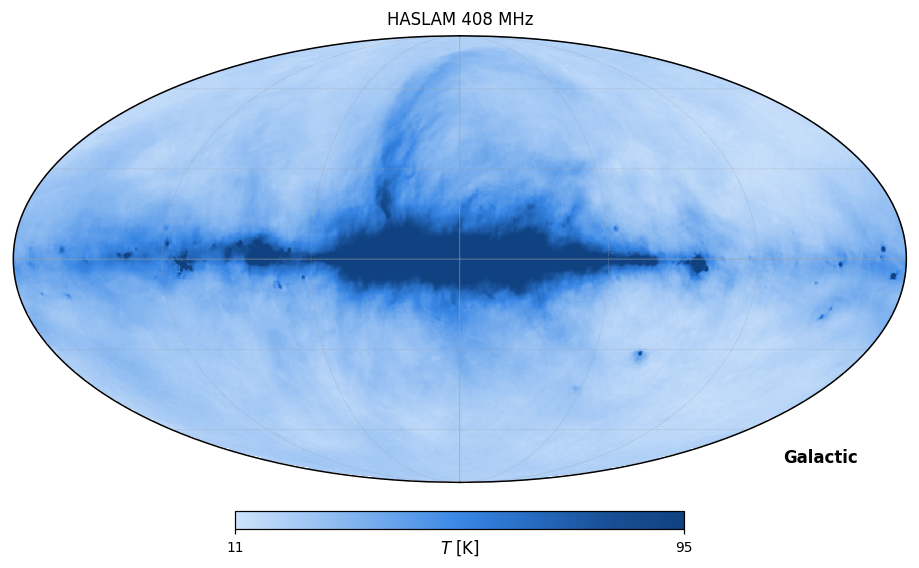

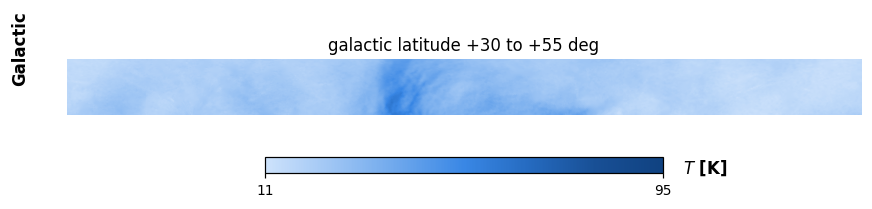

In [67]:
haslam = hp.read_map(RES / "HASLAM.fits")
# Check these explicitly before doing anything else -- they matter:
print("nside:", hp.get_nside(haslam))
print("npix: ", hp.get_map_size(haslam))

# min/max by hand: the galactic plane runs to thousands of K and
# swamps a linear scale.
lo_h, hi_h = 11, 95

hp.mollview(haslam, title="HASLAM 408 MHz", unit="$T$ [K]", coord="G", min=lo_h, max=hi_h, **MAP_KW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
# latra is GALACTIC latitude here, not TRIS's equatorial dec +42 band.
hp.cartview(haslam, latra=[30, 55], unit="$T$ [K]",
            title="galactic latitude +30 to +55 deg", coord="G", min=lo_h, max=hi_h, **MAP_KW)
plt.show()

In [68]:
print("HASLAM 408 MHz map")
print("  Any UNSEEN?", np.any(haslam == hp.UNSEEN))
print("  Any NaN?   ", np.any(np.isnan(haslam)))
print("  Any exact zero (suspicious if widespread)?", int(np.sum(haslam == 0)))

HASLAM 408 MHz map
  Any UNSEEN? False
  Any NaN?    False
  Any exact zero (suspicious if widespread)? 0


Full sky, no sentinels and no zeros — the opposite situation to ARCADE 2, so none of the
mask handling above applies to it. The header states `RING` at nside 512 and
`COORDSYS = GALACTIC`, which is the one native frame among the three datasets and the
reason the coordinate mismatch in the design document's open TODO is real: Haslam is
galactic, the TRIS work so far is equatorial, and ARCADE 2 declines to say.

---
# 04 TRIS maps

The maps stage 1 made from the drift rings — the 600 and 820 MHz points of the SED, and
the only absolutely calibrated ones with spatial structure. Section 01 looked at the
*rings*; this loads what the map-maker turned them into.

Same treatment as ARCADE 2 and Haslam: what the file contains, the pixelisation, the
maps, and how the sky it never saw is marked.

Two things about these products are deliberate and worth having in mind before the
numbers appear. The grid is **coarse on purpose** — the beam is 19–23°, so there is no
information to put on a fine grid, and stage 3 degrades to `beam.nside_new = 8` anyway.
And the pixels are selected **by beam response**, not by a declination cut: a pixel is
kept if the beam response at it exceeds `tris.beam_response_threshold` of the peak for at
least one observation.

In [69]:
from moonrunes.stage1_tris_maps import load_stage1

products = load_stage1(config)                    # nside 16, the configured run
products8 = load_stage1(                          # nside 8, the coarser comparison
    config,
    maps_path=REPO / "outputs" / "stage1_nside8" / "tris_maps_tris_haslam_v0.npz",
    manifest_path=REPO / "outputs" / "stage1_nside8" / "stage1_manifest.json",
)
GRIDS = {8: products8, 16: products}
print(products.maps_path.name, "and", products.manifest_path.name, "\n")

# The npz is the analogue of the FITS header dump above: what is in the file.
print(f"  {'array':26s}{'dtype':10s}shape")
for key, arr in products.arrays.items():
    print(f"  {key:26s}{str(arr.dtype):10s}{arr.shape}")

print("\nrun     ", products.manifest["run_name"], "written", products.manifest["written_utc"])
print("blocker 2", products.manifest["blocker_2_substitute"]["prior_equals_truth"],
      "= prior_equals_truth")

tris_maps_tris_haslam_v0.npz and stage1_manifest.json 

  array                     dtype     shape
  nside                     int64     ()
  pixel_indices             int64     (1272,)
  band_mask                 bool      (3072,)
  freq_mhz                  float64   (2,)
  effective_freq_mhz        float64   (2,)
  ref_freq_mhz              float64   ()
  sky_k                     float64   (2, 1272)
  sky_sigma_k               float64   (2, 1272)
  prior_mean_k              float64   (2, 1272)
  prior_sigma_k             float64   (2, 1272)
  truth_k                   float64   (2, 1272)
  zero_level_k              float64   (2,)
  zero_level_sigma_k        float64   (2,)
  zero_level_prior_sigma_k  float64   (2,)
  ra_deg                    float64   (2, 120)
  data_k                    float64   (2, 120)
  residual_k                float64   (2, 120)
  beam_coverage             float64   (2, 120)
  sky_full_k                float64   (2, 3072)
  sky_sigma_full_k          float64

In [70]:
sky_full = products["sky_full_k"]          # (Nfreq, npix), NaN outside the selection
eff = products["effective_freq_mhz"]
npix = sky_full.shape[1]

# Check these explicitly before doing anything else -- they matter:
print("nside:", products.nside)
print("npix: ", npix)
print("freqs:", ", ".join(f"{f:.0f} MHz (nu_eff {e:.1f})"
                          for f, e in zip(products.frequencies_mhz, eff)))
print("frame: equatorial -- stage 3 is what rotates this into the galactic frame")

sel = products.diagnostics(600)["pixel_selection"]
print(f"\npixel selection: beam response > {sel['threshold']:g} of peak, "
      f"for at least one observation")
print(f"  {sel['n_pixels']} pixels kept ({sel['sky_fraction']:.1%} of sky), "
      f"{sel['beam_power_retained']:.4%} of beam power retained")
print(f"  {sel['samples_per_pixel']:.3f} samples per pixel "
      f"-- 120 samples spread over {sel['n_pixels']} parameters")

print(f"\n{'nu [MHz]':>9}{'observed pixels':>18}{'sky fraction':>15}"
      f"{'min [K]':>10}{'median [K]':>12}{'max [K]':>10}")
for i, freq in enumerate(products.frequencies_mhz):
    m = sky_full[i]
    observed = int(np.isfinite(m).sum())
    print(f"{freq:9.0f}{observed:18d}{observed / npix:15.3f}"
          f"{np.nanmin(m):10.3f}{np.nanmedian(m):12.3f}{np.nanmax(m):10.3f}")

nside: 16
npix:  3072
freqs: 600 MHz (nu_eff 600.5), 820 MHz (nu_eff 817.8)
frame: equatorial -- stage 3 is what rotates this into the galactic frame

pixel selection: beam response > 0.01 of peak, for at least one observation
  1272 pixels kept (41.4% of sky), 99.6037% of beam power retained
  0.094 samples per pixel -- 120 samples spread over 1272 parameters

 nu [MHz]   observed pixels   sky fraction   min [K]  median [K]   max [K]
      600              1272          0.414     5.831      11.468    99.021
      820              1272          0.414     3.655       6.525    41.340


In [71]:
products.frequencies_mhz

array([600., 820.])

plotting nside 16 maps (3072 pixels, 3.665 deg/pixel)


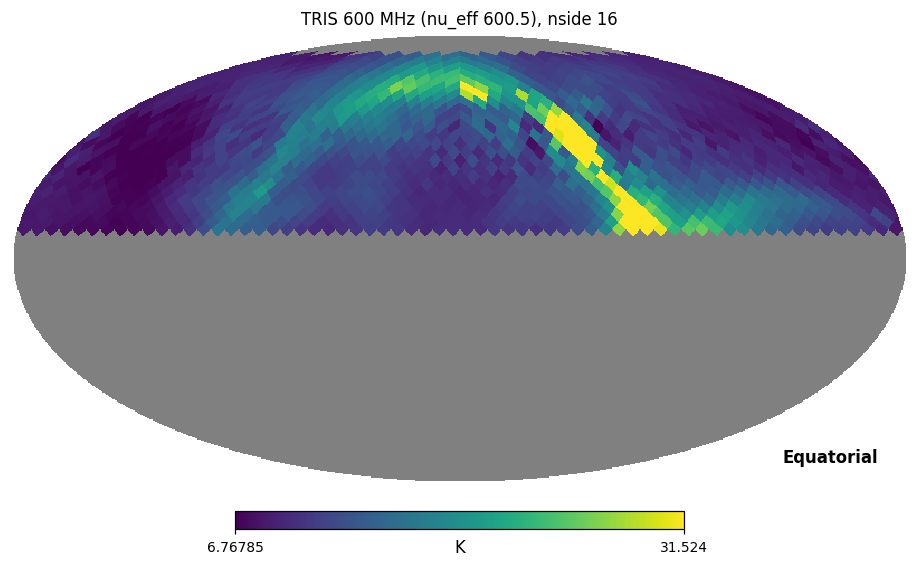

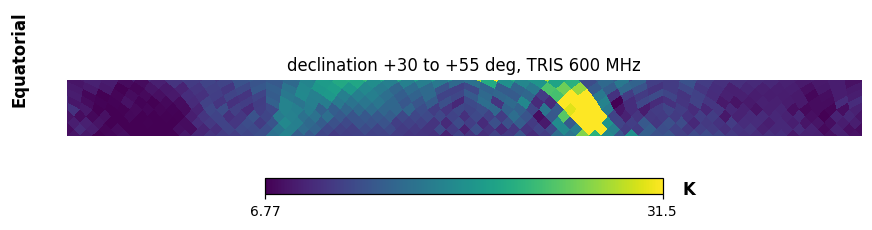

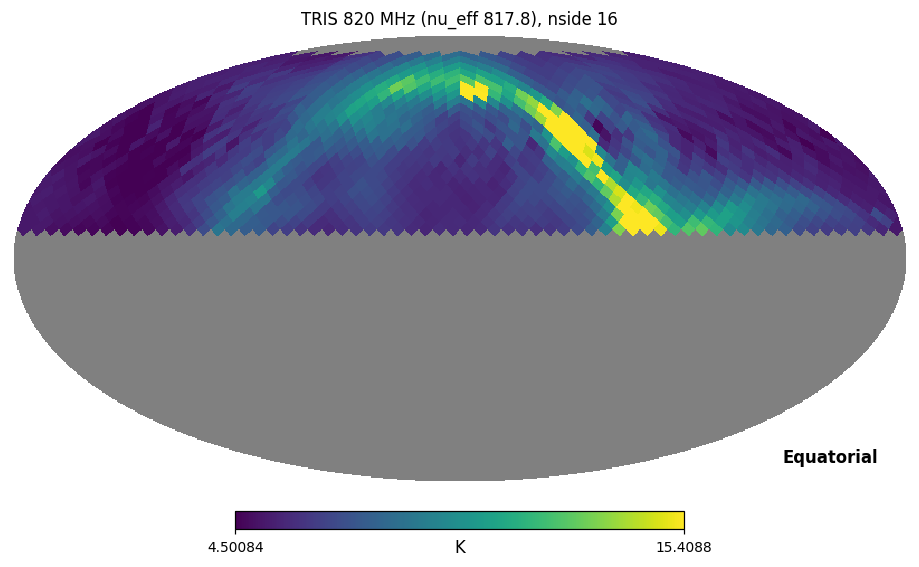

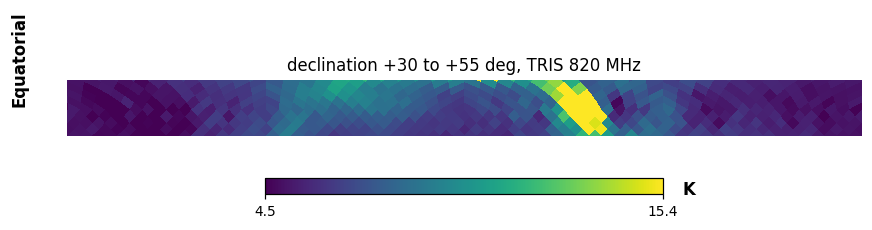

In [72]:
print(f"plotting nside {products.nside} maps "
      f"({npix} pixels, {hp.nside2resol(products.nside, arcmin=True) / 60:.3f} deg/pixel)")

for i, freq in enumerate(products.frequencies_mhz):
    m = sky_full[i]
    # Colour limits from percentiles rather than by hand: the galactic plane runs to
    # hundreds of K at 600 MHz and swamps a linear scale, exactly as it does in Haslam.
    lo, hi = np.nanpercentile(m, [2, 98])
    # No norm= here: healpy only understands "hist", "log" and "symlog" and falls back
    # to linear for anything else, so norm="auto" was never doing anything.
    hp.mollview(m, unit="K", coord="C", min=lo, max=hi,
                title=f"TRIS {freq:.0f} MHz (nu_eff {eff[i]:.1f}), nside {products.nside}")
    # latra is DECLINATION here, not galactic latitude -- these maps are equatorial,
    # so unlike sections 02 and 03 this really is a TRIS declination strip.
    hp.cartview(m, latra=[30, 55], unit="K", coord="C", min=lo, max=hi,
                title=f"declination +30 to +55 deg, TRIS {freq:.0f} MHz")
    if freq==600.:
        m_tris_600 = m
    else:
        m_tris_820 = m
plt.show()

### Is that plotted correctly?

Three things have to hold for these panels to mean what they look like, and none of them
is stated by the npz: the pixel **ordering** (RING vs NESTED), the **frame** the pixel
indices were built in, and whether `coord="C"` is therefore the right thing to pass. Each
one is silent when wrong — a NESTED map read as RING still plots, it just plots scrambled
sky — so all three are measured here rather than assumed.

The ordering test also doubles as a check on the beam-response selection. TRIS drifts
through **all** right ascensions at a fixed elevation, so whatever the beam sees at one RA
it sees at every RA: the retained set must come out as a **pure declination band**, with no
RA structure in it. If the selection had RA dependence, something would be wrong with the
pointing or the beam projection.

In [73]:
from astropy.coordinates import SkyCoord
import astropy.units as u

check = sky_full[0]
npix_all = 12 * products.nside**2

# 1. The grid is what it claims to be.
print(f"nside {products.nside}: npix {check.size} == 12 x nside^2 ({npix_all}) "
      f"-> {check.size == npix_all}")

# 2. Ordering. Read the retained pixel indices both ways and ask which one gives a
#    declination band -- the only shape a full-RA drift scan can produce.
print("\nordering: does the retained set form a declination band?")
for nest in (False, True):
    dec = 90 - np.degrees(hp.pix2ang(products.nside, products.pixel_indices,
                                     nest=nest)[0])
    all_dec = 90 - np.degrees(hp.pix2ang(products.nside, np.arange(npix_all),
                                         nest=nest)[0])
    inside = int(((all_dec >= dec.min()) & (all_dec <= dec.max())).sum())
    label = "NESTED" if nest else "RING"
    verdict = ("CONTIGUOUS" if inside == products.pixel_indices.size
               else f"ragged ({inside - products.pixel_indices.size} holes)")
    print(f"  as {label:6s}: dec {dec.min():+7.2f} .. {dec.max():+7.2f}   {verdict}")

# 3. And no RA structure: every pixel inside the band, at any RA, must be retained.
dec = 90 - np.degrees(hp.pix2ang(products.nside, products.pixel_indices)[0])
geometry = tris.tris_zenith_geometry(products["ra_deg"][0])
half_width = 0.5 * (dec.max() - dec.min())
print(f"\nband centre {0.5 * (dec.min() + dec.max()):+.2f} deg vs boresight "
      f"{geometry.boresight_dec_deg:+.4f} deg")
print(f"band half-width {half_width:.2f} deg -- how far from boresight the beam still "
      f"reaches {sel['threshold']:g} of peak")

# 4. Frame. Treat every pixel centre as equatorial, convert to galactic, and ask where
#    the brightest sky sits. If the map were really galactic, the hot pixels would land
#    anywhere but b = 0.
theta, phi = hp.pix2ang(products.nside, np.arange(check.size))
b_deg = SkyCoord(ra=np.degrees(phi) * u.deg, dec=(90 - np.degrees(theta)) * u.deg,
                 frame="icrs").galactic.b.deg
observed = np.isfinite(check)
hottest = observed & (check > np.nanpercentile(check, 99))
print(f"\nhottest 1% of observed pixels: median |b| = "
      f"{np.median(np.abs(b_deg[hottest])):.2f} deg")
print(f"all observed pixels:           median |b| = "
      f"{np.median(np.abs(b_deg[observed])):.2f} deg")
print("-> the bright structure is the galactic plane, so the pixels are equatorial")
print("   and coord='C' (which labels, and does NOT rotate) is the right call.")

nside 16: npix 3072 == 12 x nside^2 (3072) -> True

ordering: does the retained set form a declination band?
  as RING  : dec   +9.59 ..  +75.34   CONTIGUOUS
  as NESTED: dec  -38.68 ..  +87.08   ragged (1256 holes)

band centre +42.47 deg vs boresight +42.4333 deg
band half-width 32.87 deg -- how far from boresight the beam still reaches 0.01 of peak

hottest 1% of observed pixels: median |b| = 2.14 deg
all observed pixels:           median |b| = 28.91 deg
-> the bright structure is the galactic plane, so the pixels are equatorial
   and coord='C' (which labels, and does NOT rotate) is the right call.


All of it holds: the grid is a valid nside 16 HEALPix map, the indices are **RING**, the
retained set is a **contiguous declination band with no RA structure** — the only shape a
full-RA drift scan can make — and the hottest 1% of pixels sit at a small median |b|
against ~30° for the band as a whole, so the Galaxy is where an equatorial map should put
it.

The band's half-width is the physically interesting number: it is how far off boresight
the beam still returns 1% of its peak, measured rather than assumed. The old
`dec_half_width_deg: 45.0` was a guess at the same quantity, and a generous one.

These maps are coarse by design, but no longer overwhelmingly prior-driven the way the
nside 64 version was: the posterior σ beats the prior by more than 5% for 388 of 1272
pixels at 600 MHz (it was 2 of 25704). `03_diagnostics.ipynb` measures that properly.

## How is the sky it never saw marked?

The same question asked of ARCADE 2, and the third distinct answer. A TRIS map is
partial-sky by construction — the beam only ever reaches part of the sky from a fixed
elevation.

In [74]:
for i, freq in enumerate(products.frequencies_mhz):
    m = sky_full[i]
    nan_count = int(np.isnan(m).sum())
    print(f"TRIS {freq:.0f} MHz map")
    print("  Any UNSEEN?", np.any(m == hp.UNSEEN))
    print("  Any NaN?   ", np.any(np.isnan(m)),
          f"-- {nan_count}/{npix} = {nan_count / npix * 100:.1f}% of pixels")
    print("  Exact zeros (suspicious if widespread):", int(np.sum(m == 0)))
    print()

print("band_mask in the npz says the same thing without the sentinel:",
      int(products['band_mask'].sum()), "observed pixels")

TRIS 600 MHz map
  Any UNSEEN? False
  Any NaN?    True -- 1800/3072 = 58.6% of pixels
  Exact zeros (suspicious if widespread): 0

TRIS 820 MHz map
  Any UNSEEN? False
  Any NaN?    True -- 1800/3072 = 58.6% of pixels
  Exact zeros (suspicious if widespread): 0

band_mask in the npz says the same thing without the sentinel: 1272 observed pixels


So the three datasets mark unobserved sky three different ways, and nothing in any file
says which convention it used:

| dataset | unobserved sky | mask recoverable from |
|---|---|---|
| **TRIS** (stage 1) | `NaN` — and an explicit `band_mask` in the npz | either; the `band_mask` is the reliable one |
| **ARCADE 2** | exact `0.0` | the zeros, and only the zeros |
| **Haslam** | nothing — full sky | n/a |

None of them uses `hp.UNSEEN`. Step 0.3 of `tris_haslam_pipeline.md` needs a boolean mask
per dataset, and this table is where each one comes from.

The other thing these maps carry that the others do not is a **per-pixel posterior σ**
(`sky_sigma_k`), which the SED fit wants as its weights.

# Check if HASLAM and TRIS have the same masking pattern

In [75]:
maps_to_check = {
    'Haslam': haslam,
    'TRIS 600 MHz': m_tris_600,
    'TRIS 820 MHz': m_tris_820,
}

for name, m in maps_to_check.items():
    n_zero = np.sum(m == 0)
    n_unseen = np.sum(m == hp.UNSEEN)
    n_nan = np.sum(np.isnan(m))
    pct_zero = n_zero / len(m) * 100
    print(f'{name}: exact-zero={n_zero} ({pct_zero:.2f}%), '
          f'UNSEEN={n_unseen}, NaN={n_nan}')

Haslam: exact-zero=0 (0.00%), UNSEEN=0, NaN=0
TRIS 600 MHz: exact-zero=0 (0.00%), UNSEEN=0, NaN=1800
TRIS 820 MHz: exact-zero=0 (0.00%), UNSEEN=0, NaN=1800


## The annulus

TRIS is a drift scan: the horn is parked and the sky rotates past it, so it sees every
right ascension at one band of declination. The footprint therefore has to be an
**annulus** — and from the celestial pole it should look like one literally.

The left panel is the coverage alone. The right is the temperature with the **Galactic
plane traced over it**: the plane is not a defect in the annulus, it is the brightest
thing in the radio sky at these frequencies, and it crosses the band twice.

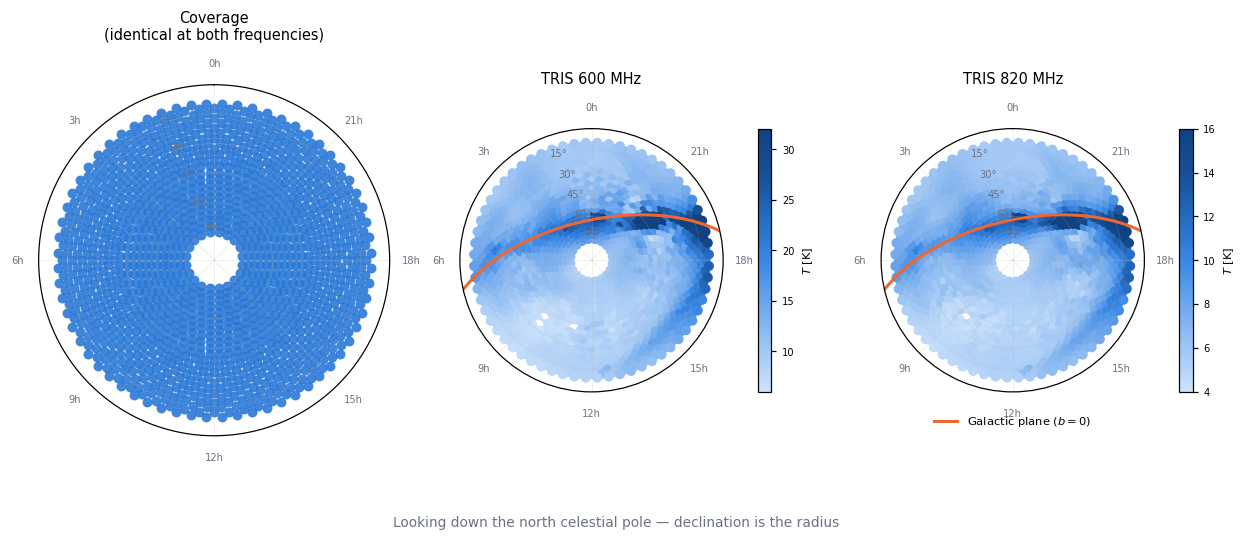

observed pixels per RA quadrant (an annulus must be flat across RA):
  RA   0- 90 deg:   318
  RA  90-180 deg:   318
  RA 180-270 deg:   318
  RA 270-360 deg:   318


In [76]:
sky = {f: products["sky_full_k"][products.index(f)] for f in (600, 820)}

# One colour scale PER FREQUENCY.  820 MHz is roughly half the temperature of
# 600 MHz -- synchrotron falls as nu^beta -- so a scale shared across frequency
# would flatten the 820 panel into a single tone and hide its structure.
LIMITS = {f: (np.floor(np.nanpercentile(m, 2)), np.ceil(np.nanpercentile(m, 98)))
          for f, m in sky.items()}
lo, hi = LIMITS[600]

# Azimuthal equidistant about the north celestial pole: radius is co-declination,
# so it is LINEAR in dec and both edges of the band stay visible.  An orthographic
# view squashes the outer edge to nothing -- the annulus then reads as a filled disc.
theta_all, phi_all = hp.pix2ang(products.nside, np.arange(sky[600].size))
co_dec = np.degrees(theta_all)
ra_rad = phi_all
seen = np.isfinite(sky[600])
size = (60.0 / products.nside) ** 2 * 3

plane = SkyCoord(l=np.linspace(0, 360, 1440) * u.deg, b=np.zeros(1440) * u.deg,
                 frame="galactic").icrs
north = plane.dec.deg > 0

fig, axes = plt.subplots(1, 3, figsize=(14, 5.0),
                         subplot_kw={"projection": "polar"})
for ax in axes:
    ax.set_theta_zero_location("N")
    ax.set_rlim(0, 90)
    ax.set_rticks([15, 30, 45, 60, 75])
    ax.set_yticklabels(["75°", "60°", "45°", "30°", "15°"], fontsize=6.5,
                       color="#6b7280")
    ax.set_xticks(np.radians(np.arange(0, 360, 45)))
    ax.set_xticklabels([f"{h}h" for h in range(0, 24, 3)], fontsize=6.5,
                       color="#6b7280")
    ax.grid(alpha=0.25, lw=0.5)
    ax.set_facecolor("white")

axes[0].scatter(ra_rad[seen], co_dec[seen], s=size, c="#2a78d6", linewidths=0,
                alpha=0.9)
axes[0].set_title("Coverage\n(identical at both frequencies)", fontsize=9.5, pad=12)

for ax, freq in zip(axes[1:], (600, 820)):
    vlo, vhi = LIMITS[freq]
    sc = ax.scatter(ra_rad[seen], co_dec[seen], s=size, c=sky[freq][seen],
                    cmap=SEQ, vmin=vlo, vmax=vhi, linewidths=0)
    ax.plot(np.radians(plane.ra.deg[north]), 90 - plane.dec.deg[north],
            color="#eb6834", lw=2, label="Galactic plane ($b=0$)")
    ax.set_title(f"TRIS {freq} MHz", fontsize=9.5, pad=12)
    cb = fig.colorbar(sc, ax=ax, shrink=0.62, pad=0.10)
    cb.set_label("$T$ [K]", fontsize=7.5)
    cb.ax.tick_params(labelsize=6.5)
axes[2].legend(loc="lower center", fontsize=7.5, frameon=False,
               bbox_to_anchor=(0.5, -0.18))
fig.suptitle("Looking down the north celestial pole — declination is the radius",
             fontsize=9, color="#6b7280", y=0.03)
plt.show()

print("observed pixels per RA quadrant (an annulus must be flat across RA):")
ra_deg_all = np.degrees(phi_all)
for lo_ra, hi_ra in ((0, 90), (90, 180), (180, 270), (270, 360)):
    q = seen & (ra_deg_all >= lo_ra) & (ra_deg_all < hi_ra)
    print(f"  RA {lo_ra:3d}-{hi_ra:3d} deg: {int(q.sum()):5d}")

## nside 8 against nside 16

Both grids, same data, same beam-response threshold. The maps are plotted on a **shared
colour scale** so the panels are directly comparable — a per-panel scale would make two
different skies look alike.

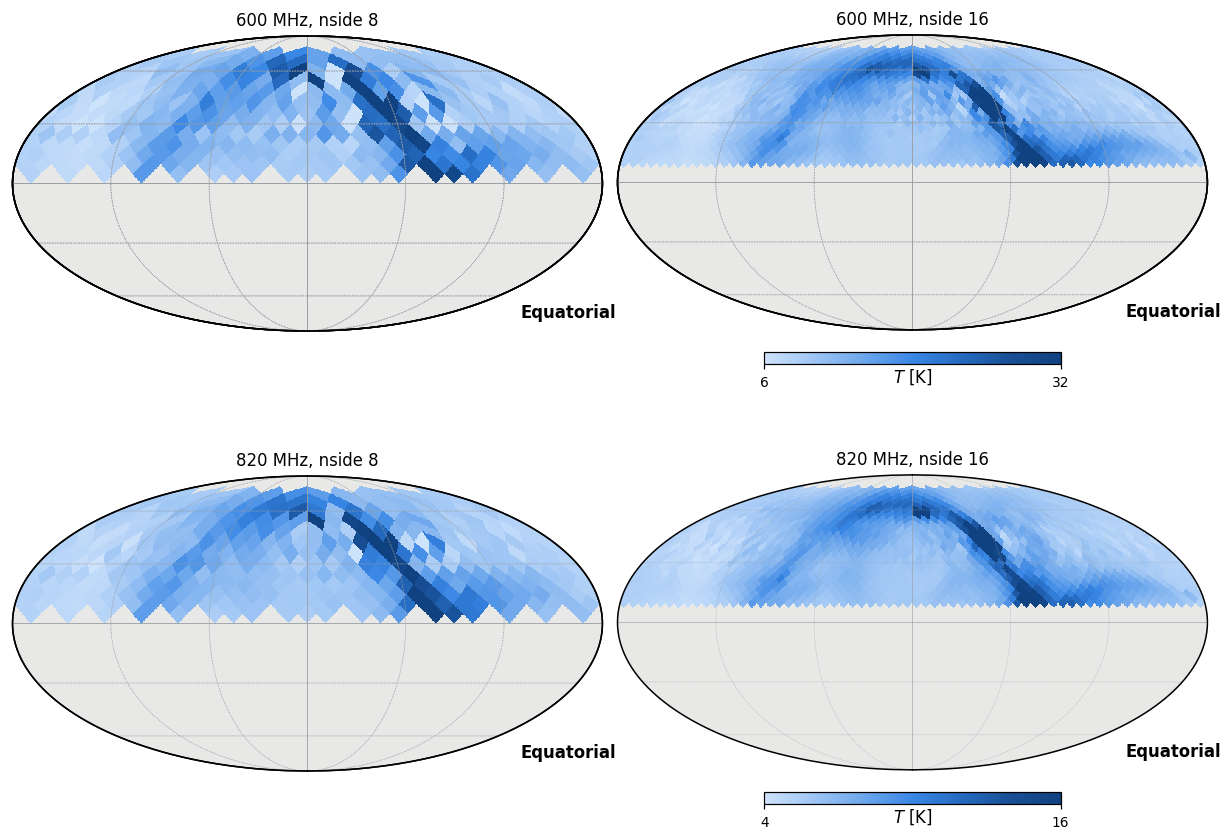


600 MHz                   nside 8    nside 16
pixels retained                344        1272
sky fraction                 0.448       0.414
beam power kept            0.99728     0.99604
zero level [K]             +1.7385     +1.7442
zero level sigma            0.0825      0.0425
reduced chi2                  5.65        3.09
sigma shrinkage              0.874       0.983
pixels tightened               202         388

820 MHz                   nside 8    nside 16
pixels retained                344        1272
sky fraction                 0.448       0.414
beam power kept            0.99728     0.99604
zero level [K]             +0.4836     +0.5101
zero level sigma            0.0527      0.0269
reduced chi2                  2.58        3.22
sigma shrinkage              0.909       0.991
pixels tightened               193         201


In [77]:
# Rows are frequency, columns are grid.  Each ROW carries its own colour scale
# (see above); the two grids within a row share one, which is what makes the
# left-right comparison honest.
fig = plt.figure(figsize=(11, 8))
panel = 1
for freq in (600, 820):
    vlo, vhi = LIMITS[freq]
    for nside, prod in GRIDS.items():
        m = prod["sky_full_k"][prod.index(freq)]
        hp.mollview(m, coord="C", min=vlo, max=vhi, unit="$T$ [K]",
                    title=f"{freq} MHz, nside {nside}", sub=(2, 2, panel),
                    fig=fig.number, cbar=(panel % 2 == 0), **MAP_KW)
        hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
        panel += 1
plt.show()

for freq in (600, 820):
    print(f"\n{freq} MHz{'':14}{'nside 8':>12}{'nside 16':>12}")
    rows = [
        ("pixels retained",  lambda p: p.diagnostics(freq)["pixel_selection"]["n_pixels"], "{:d}"),
        ("sky fraction",     lambda p: p.diagnostics(freq)["pixel_selection"]["sky_fraction"], "{:.3f}"),
        ("beam power kept",  lambda p: p.diagnostics(freq)["pixel_selection"]["beam_power_retained"], "{:.5f}"),
        ("zero level [K]",   lambda p: p.diagnostics(freq)["zero_level_k"], "{:+.4f}"),
        ("zero level sigma", lambda p: p.diagnostics(freq)["zero_level_sigma_k"], "{:.4f}"),
        ("reduced chi2",     lambda p: p.diagnostics(freq)["reduced_chi_square"], "{:.2f}"),
        ("sigma shrinkage",  lambda p: p.diagnostics(freq)["sigma_shrinkage_median"], "{:.3f}"),
        ("pixels tightened", lambda p: p.diagnostics(freq)["pixels_shrunk_gt_5pct"], "{:d}"),
    ]
    for label, get, fmt in rows:
        print(f"{label:<22}{fmt.format(get(products8)):>12}{fmt.format(get(products)):>12}")

### Where the annulus sits, and what each grid resolves

The profile below is the one place the two grids can be compared without the eye doing
the work. Declination is the only coordinate the coverage depends on, so a profile
against it says everything about the footprint: where the band starts and stops, and how
sharply.

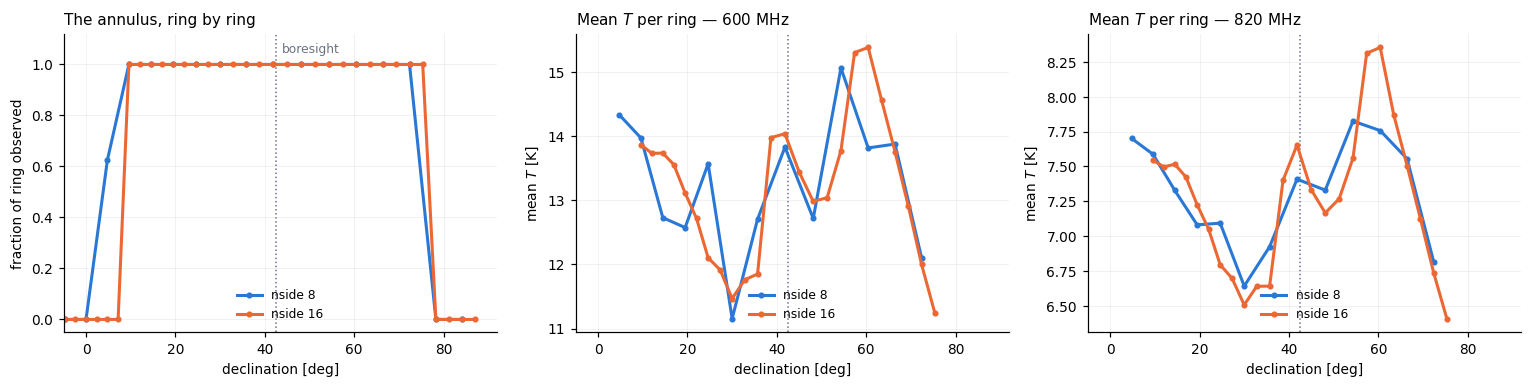

nside  8: band  +4.78 .. +72.39 deg   centre +38.58   offset from boresight -3.85 deg
nside 16: band  +9.59 .. +75.34 deg   centre +42.47   offset from boresight +0.03 deg

mean T over the band at each frequency, and the index between them:
  nside  8: 13.211 K at 600,  7.287 K at 820  ->  beta = -1.926
  nside 16: 13.161 K at 600,  7.248 K at 820  ->  beta = -1.931


In [78]:
# HEALPix pixel centres sit on discrete iso-latitude RINGS, so bin on the rings
# themselves.  Uniform declination bins put zero pixels in some bins at coarse
# nside, which draws holes in a footprint that has none.
def ring_profile(prod, nside, freq):
    m = prod["sky_full_k"][prod.index(freq)]
    # Round BOTH sides before matching: the ring declinations come back with
    # float noise, so comparing raw values against rounded ones matches nothing.
    dec_all = np.round(90 - np.degrees(hp.pix2ang(nside, np.arange(m.size))[0]), 6)
    observed_here = np.isfinite(m)
    rings = np.unique(dec_all)
    frac = np.array([observed_here[dec_all == r].mean() for r in rings])
    mean_t = np.array([np.nanmean(m[(dec_all == r) & observed_here])
                       if (observed_here & (dec_all == r)).any() else np.nan
                       for r in rings])
    return rings, frac, mean_t

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

for nside, prod in GRIDS.items():
    colour = GRID_COLOUR[nside]
    rings, frac, _ = ring_profile(prod, nside, 600)      # coverage is the same
    axes[0].plot(rings, frac, color=colour, lw=2, marker="o", ms=3,
                 label=f"nside {nside}")
    for ax, freq in zip(axes[1:], (600, 820)):
        rings, _, mean_t = ring_profile(prod, nside, freq)
        good = np.isfinite(mean_t)
        ax.plot(rings[good], mean_t[good], color=colour, lw=2, marker="o", ms=3,
                label=f"nside {nside}")

axes[0].set_ylabel("fraction of ring observed")
axes[0].set_ylim(-0.05, 1.12)
axes[0].set_title("The annulus, ring by ring", fontsize=10, loc="left")
axes[1].set_ylabel("mean $T$ [K]")
axes[1].set_title("Mean $T$ per ring — 600 MHz", fontsize=10, loc="left")
axes[2].set_ylabel("mean $T$ [K]")
axes[2].set_title("Mean $T$ per ring — 820 MHz", fontsize=10, loc="left")
for ax in axes:
    ax.set_xlabel("declination [deg]")
    ax.set_xlim(-5, 92)
    ax.grid(alpha=0.18, lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(fontsize=8, frameon=False, loc="lower center")
    ax.axvline(geometry.boresight_dec_deg, color="#6b7280", lw=1, ls=":", zorder=0)
axes[0].annotate("boresight", xy=(geometry.boresight_dec_deg, 1.06),
                 xytext=(4, 0), textcoords="offset points", fontsize=8,
                 color="#6b7280", va="center")
fig.tight_layout()
plt.show()

for nside, prod in GRIDS.items():
    dec = 90 - np.degrees(hp.pix2ang(nside, prod.pixel_indices)[0])
    print(f"nside {nside:2d}: band {dec.min():+6.2f} .. {dec.max():+6.2f} deg   "
          f"centre {0.5*(dec.min()+dec.max()):+6.2f}   "
          f"offset from boresight "
          f"{0.5*(dec.min()+dec.max()) - geometry.boresight_dec_deg:+.2f} deg")

print("\nmean T over the band at each frequency, and the index between them:")
for nside, prod in GRIDS.items():
    t6 = np.nanmean(prod["sky_full_k"][prod.index(600)])
    t8 = np.nanmean(prod["sky_full_k"][prod.index(820)])
    beta = np.log(t6 / t8) / np.log(600.5 / 817.8)
    print(f"  nside {nside:2d}: {t6:6.3f} K at 600, {t8:6.3f} K at 820  ->  "
          f"beta = {beta:+.3f}")

---
## Summary

### 01 — the TRIS rings

* **Two absolute rings**, 120 samples each on a shared, non-uniform RA grid, each with one
  0.000 K row that forces an uncertainty floor.
* **A zero level** that dwarfs the statistical errors and is asymmetric at 820 MHz —
  carried as a nuisance parameter with a 0.5 K symmetric prior, recorded as a decision.
* **A beam from the archive's own cuts**, with real below-horizon response that the
  horizon mask removes. Its E/H asymmetry is now a Step 0 problem: TRIS is the coarsest of
  the three datasets, so it sets the common resolution everything else is smoothed down to.
* **Rayleigh–Jeans temperatures including the CMB monopole**, settled by the physics
  rather than a header.
* **GSM2008 as prior *and* truth**, measured here as ~1.9 K cold at 600 MHz and ~0.6 K
  cold at 820 MHz. Under the SED design the prior question is moot, but the measurement
  stands: read the offset as a statement about GSM2008, not about the archive's zero point.

### 02 — can ARCADE 2 carry the two extra SED points?

The data is there, and three properties of the files decide how it has to be handled:

* **the sky it never saw is stored as exact zero**, with no `UNSEEN` and no `NaN`. The
  mask has to be rebuilt from the zeros, and rebuilt *before* smoothing;
* **`NESTED` at nside 16**, a 3.7° pixel. Coarse next to Haslam's nside 512, though still
  fine against the ~23° beam everything is being smoothed to;
* **no `COORDSYS` in the header**, so the galactic frame assumed in the plots here is
  unconfirmed — which is the open coordinate TODO, not a detail.

### 03 — Haslam 408 MHz

Full sky at nside 512, `RING`, `COORDSYS = GALACTIC`, no sentinels and no zero pixels.
The galactic plane runs to thousands of K, hence the hand-set colour limits. This is the
`res/` copy; stage 2 reads its own from the `pygdsm` cache, and the two are not compared
here.

### 04 — the TRIS maps

Stage 1's products at **nside 16** — coarse on purpose, since the beam is 19–23° and stage
3 degrades to nside 8 regardless — **equatorial**, covering **41.4% of the sky**. Pixels
are selected by **beam response** (kept if the response exceeds 1% of peak at any one
observation), not by a declination cut; that retains 99.60% of the beam power and comes
out as a clean band because the scan covers all RA. `NaN` off-selection, with an explicit
`band_mask` alongside, and a per-pixel posterior σ the SED fit should weight by.

### What sections 02–04 add up to

The three datasets meet in the SED fit, and they agree on nothing that matters
operationally: three pixelisations (nside 16, 512, 16), three frames (unstated, galactic,
equatorial), and three ways of marking unobserved sky (zeros, nothing, `NaN`). Step 0 of
`tris_haslam_pipeline.md` exists to reconcile the first and third; the second is still the
open coordinate TODO, and ARCADE 2's silent header is the part of it that cannot be
settled from the files alone.

---

Next: `03_diagnostics.ipynb` for the stage 1 map diagnostics, and
`02_build_berkhijsen_prior.ipynb` for the stage 2 products. Both were written under the
Gibbs design that `tris_haslam_pipeline.md` now supersedes.

---
# 05 — Every map in `res/`, side by side

This section discovers what is in `res/` each time it runs, so a file added there shows up
without editing anything:

* **every `*.fits` HEALPix map** gets one panel. The grid is 2 columns with as many rows as
  the maps need. Each map is drawn in its own declared frame, with this notebook's palette
  (`MAP_KW`), graticule and percentile colour limits, and with unobserved sky in the
  recessive grey;
* **every map is also cut along the TRIS strip** (Dec +30° to +55°) in a second figure. It is
  the same rectangular plate-carrée slice as the per-map `cartview` panels above, but each
  pixel is looked up at its own RA/Dec, so the vertical axis is truly declination, not
  Galactic latitude. RA increases to the left;
* **every TRIS drift ring** (`TRIS_absolute_*.txt` files that read as rings) becomes a row
  in the table, describing the stage 1 map it turns into. Point sets and the beam profile
  are recognised and listed as skipped.

**Where each number comes from**, in order of preference:

1. the FITS header: `FREQ`, `TUNIT1`, `BEAMSIZE` / `BEAMSZ`, `COORDSYS` / `SKYCOORD`,
   `ORDERING`, `NSIDE`;
2. the filename, for the frequency (e.g. `…_1400MHZ`);
3. `EXTERNAL_METADATA` below, for facts the file does not carry, each with its source.

Anything still unknown prints as `?`; nothing is guessed. **Unobserved sky** is detected
from the data: `hp.UNSEEN`, NaN, the FITS null −32768, and exact zeros once they cover more
than 1% of the sky (ARCADE 2's convention).

**The TRIS strip** is overlaid as in section 04: Dec +30° to +55° (orange), with the
boresight at Dec +42.4° dashed. It is drawn in each map's own frame, so on these Galactic
maps it appears curved. The strip is the region section 04 zooms into. Stage 1's actual
footprint is wider (Dec +4.8° to +72.4° at nside 8), because it keeps every pixel the beam
reaches.

In [2]:
import re
from astropy.coordinates import SkyCoord
import astropy.units as u

FITS_NULL = -32768.0
ZERO_AS_MASK_FRACTION = 0.01     # exact zeros over >1% of the sky are a mask, not sky
UNIT_TO_KELVIN = {"K": 1.0, "MK": 1e-3}   # upper-cased TUNIT / external unit

# Facts the files do not carry themselves, keyed by filename, each with its source.
# A file missing from here still gets plotted; the table just shows "?" for what it lacks.
EXTERNAL_METADATA = {
    "HASLAM.fits": dict(name="Haslam 408 MHz"),       # display name only
    "MAIPU_45mhZ.fits": dict(
        name="Maipu + MU 45 MHz", unit="K", fwhm="4.6° × 2.4° (Maipu) / 3.6° (MU)",
        source="LAMBDA fg_maipu_info; Guzmán et al. 2011"),
    "STOCKERT_VILLA_1400MHZ.fits": dict(
        name="Stockert + Villa-Elisa 1420 MHz", unit="mK", freq_mhz=1420.0, fwhm="35.4′",
        source="LAMBDA fg_stockert_villa_info; Reich 1982, Testori et al. 2001"),
    "ARCADE2_315.fits": dict(name="ARCADE 2 3.15 GHz", unit="K",
                             source="LAMBDA arcade_maps_info (K thermodynamic)"),
    "ARCADE2_341.fits": dict(name="ARCADE 2 3.41 GHz", unit="K",
                             source="LAMBDA arcade_maps_info (K thermodynamic)"),
}

def merged_header(path):
    # All HDU headers as one dict; later HDUs (the data table) win on clashes.
    out = {}
    with fits.open(path) as hdul:
        for hdu in hdul:
            out.update({k: hdu.header[k] for k in hdu.header if k not in ("COMMENT", "HISTORY")})
    return out

def frequency_mhz(header, filename):
    raw = header.get("FREQ")
    if raw is not None:
        text = str(raw).strip()
        number = float(re.match(r"[\d.]+", text).group())
        if "GHZ" in text.upper():
            return number * 1e3, "header FREQ"
        return number, "header FREQ"            # MHz, as both FREQ forms here are
    hit = re.search(r"(\d+(?:\.\d+)?)\s*(MHZ|GHZ)", filename.upper())
    if hit:
        return float(hit.group(1)) * (1e3 if hit.group(2) == "GHZ" else 1.0), "filename"
    return None, None

def beam_fwhm(header):
    if "BEAMSIZE" in header:                    # Haslam: arcmin
        return f"{float(header['BEAMSIZE']):.0f}′", "header BEAMSIZE"
    if "BEAMSZ" in header:                      # ARCADE 2: degrees
        return f"{float(header['BEAMSZ']):.1f}°", "header BEAMSZ"
    return None, None

def unobserved_mask(sky):
    mask = ~np.isfinite(sky) | (sky == hp.UNSEEN) | (sky == FITS_NULL)
    zeros = sky == 0
    if zeros.mean() > ZERO_AS_MASK_FRACTION:
        mask |= zeros
    return mask

def describe(path):
    header = merged_header(path)
    extra = EXTERNAL_METADATA.get(path.name, {})
    sky = hp.read_map(path, field=0)            # reordered to RING on read
    nside = hp.get_nside(sky)

    freq, freq_src = frequency_mhz(header, path.name)
    if freq is None and "freq_mhz" in extra:
        freq, freq_src = extra["freq_mhz"], "external"
    elif freq is not None and "freq_mhz" in extra and abs(extra["freq_mhz"] - freq) > 1:
        freq, freq_src = extra["freq_mhz"], f"external (filename says {freq:.0f})"

    unit = str(header.get("TUNIT1", "")).strip() or extra.get("unit")
    unit_src = "header TUNIT1" if header.get("TUNIT1") else ("external" if unit else None)
    fwhm, fwhm_src = beam_fwhm(header)
    if fwhm is None and "fwhm" in extra:
        fwhm, fwhm_src = extra["fwhm"], "external"

    frame_key = next((k for k in ("COORDSYS", "SKYCOORD") if k in header), None)
    frame_raw = header.get(frame_key) if frame_key else None
    frame = None if frame_raw is None else str(frame_raw).strip().upper()[0]
    frame = {"Q": "C"}.get(frame, frame)        # healpy's "Q" is equatorial too

    masked = unobserved_mask(sky)
    scale = UNIT_TO_KELVIN.get(str(unit).upper()) if unit else None
    shown = np.where(masked, np.nan, sky * (scale if scale else 1.0))
    sources = sorted({s for s in (freq_src, unit_src, fwhm_src) if s and "external" in s})
    return dict(file=path.name, name=extra.get("name", path.stem), freq_mhz=freq,
                frame_src=f"header {frame_key}" if frame_key else None,
                nside=nside, ordering=str(header.get("ORDERING", "?")).strip(),
                frame=frame, unit=unit, in_kelvin=scale is not None, fwhm=fwhm,
                fwhm_src=fwhm_src, freq_src=freq_src, unit_src=unit_src,
                external=extra.get("source") if sources else None,
                n_unobserved=int(masked.sum()), sky=shown)

MAPS = sorted((describe(p) for p in sorted(RES.glob("*.fits"))),
              key=lambda m: (m["freq_mhz"] is None, m["freq_mhz"] or 0.0))

# The TRIS products: classify each text file by trying to read it as a ring.
TRIS_RINGS, SKIPPED = [], []
for path in sorted(RES.glob("TRIS_*.txt")):
    try:
        ring = tris.read_tris_ring(path)
        TRIS_RINGS.append((path.name, ring))
    except Exception as err:
        SKIPPED.append((path.name, type(err).__name__))

print(f"res/: {len(MAPS)} HEALPix maps, {len(TRIS_RINGS)} TRIS rings, "
      f"{len(SKIPPED)} other TRIS files skipped")
for m in MAPS:
    print(f"  {m['file']:<30} nside {m['nside']:4d} {m['ordering']:<6} frame {m['frame'] or '?'}"
          f"  unit {m['unit'] or '?':<3} unobserved {m['n_unobserved']:7d} px")
for name, ring in TRIS_RINGS:
    print(f"  {name:<30} ring: {ring.ra_deg.size} samples, ν_eff {ring.effective_frequency_mhz:.1f} MHz")
for name, why in SKIPPED:
    print(f"  {name:<30} not a ring ({why}) -- skipped")
missing_frame = [m["file"] for m in MAPS if m["frame"] is None]
if missing_frame:
    print(f"\nWARNING: no frame keyword in {missing_frame}; drawn as Galactic, check it")

res/: 5 HEALPix maps, 2 TRIS rings, 2 other TRIS files skipped
  MAIPU_45mhZ.fits               nside   64 NESTED frame G  unit K   unobserved    1877 px
  HASLAM.fits                    nside  512 RING   frame G  unit K   unobserved       0 px
  STOCKERT_VILLA_1400MHZ.fits    nside  256 NESTED frame G  unit mK  unobserved      47 px
  ARCADE2_315.fits               nside   16 NESTED frame G  unit K   unobserved    2852 px
  ARCADE2_341.fits               nside   16 NESTED frame G  unit K   unobserved    2840 px
  TRIS_absolute_600.txt          ring: 120 samples, ν_eff 600.5 MHz
  TRIS_absolute_820.txt          ring: 120 samples, ν_eff 817.8 MHz
  TRIS_Beam_Profile.txt          not a ring (ValueError) -- skipped
  TRIS_absolute_2500MHz.txt      not a ring (ValueError) -- skipped


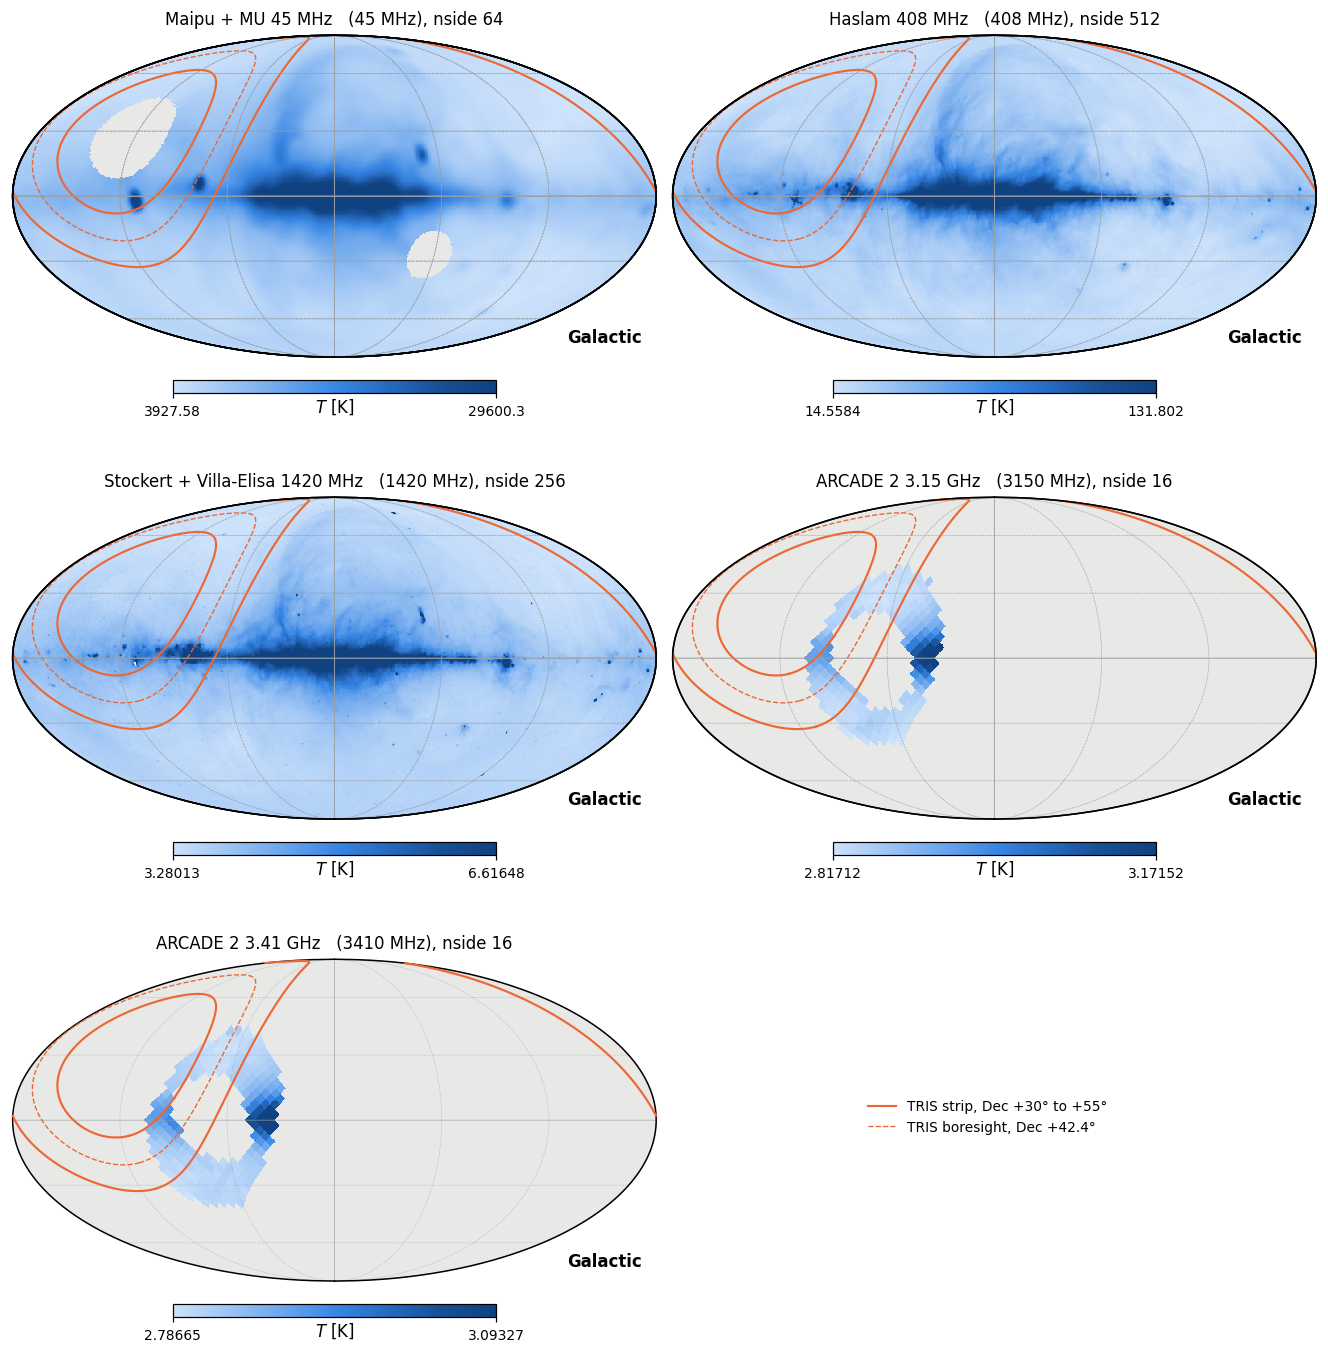

In [3]:
TRIS_STRIP_DEC = (30.0, 55.0)
TRIS_BORESIGHT_DEC = tris.TRIS_SITE_LATITUDE_DEG
STRIP_COLOUR = "#eb6834"
ASTROPY_FRAME = {"G": "galactic", "C": "icrs", "E": "barycentrictrueecliptic"}

def draw_dec_line(dec_deg, frame, **kw):
    # A line of constant declination in the map's own frame.  Split it wherever it wraps
    # across the lon = 180° edge, or it streaks across the whole map.
    ra = np.linspace(0.0, 360.0, 1441)
    coords = SkyCoord(ra=ra * u.deg, dec=np.full(ra.size, dec_deg) * u.deg)
    coords = coords.transform_to(ASTROPY_FRAME[frame]).spherical
    lon = (coords.lon.deg + 180.0) % 360.0 - 180.0
    breaks = np.flatnonzero(np.abs(np.diff(lon)) > 180.0) + 1
    for lon_seg, lat_seg in zip(np.split(lon, breaks), np.split(coords.lat.deg, breaks)):
        hp.projplot(lon_seg, lat_seg, lonlat=True, **kw)

N_COLS = 2
n_rows = int(np.ceil(len(MAPS) / N_COLS))
fig = plt.figure(figsize=(6 * N_COLS, 4.2 * n_rows))
for k, m in enumerate(MAPS):
    frame = m["frame"] or "G"
    lo, hi = np.nanpercentile(m["sky"], [2, 98])     # percentile limits, as everywhere here
    unit = "$T$ [K]" if m["in_kelvin"] else f"[{m['unit'] or 'unit unknown'}]"
    freq = "" if m["freq_mhz"] is None else f"   ({m['freq_mhz']:g} MHz)"
    hp.mollview(m["sky"], coord=frame, sub=(n_rows, N_COLS, k + 1), fig=fig.number,
                min=lo, max=hi, unit=unit, title=f"{m['name']}{freq}, nside {m['nside']}",
                **MAP_KW)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
    for dec in TRIS_STRIP_DEC:
        draw_dec_line(dec, frame, color=STRIP_COLOUR, lw=1.4)
    draw_dec_line(TRIS_BORESIGHT_DEC, frame, color=STRIP_COLOUR, lw=0.9, ls="--")

handles = [plt.Line2D([], [], color=STRIP_COLOUR, lw=1.4),
           plt.Line2D([], [], color=STRIP_COLOUR, lw=0.9, ls="--")]
labels = [f"TRIS strip, Dec +{TRIS_STRIP_DEC[0]:.0f}° to +{TRIS_STRIP_DEC[1]:.0f}°",
          f"TRIS boresight, Dec +{TRIS_BORESIGHT_DEC:.1f}°"]
if len(MAPS) % N_COLS:          # an empty last slot: put the legend there
    fig.legend(handles, labels, loc="center", frameon=False, fontsize=9,
               bbox_to_anchor=(0.75, 0.5 / n_rows))
else:
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=9)
plt.show()

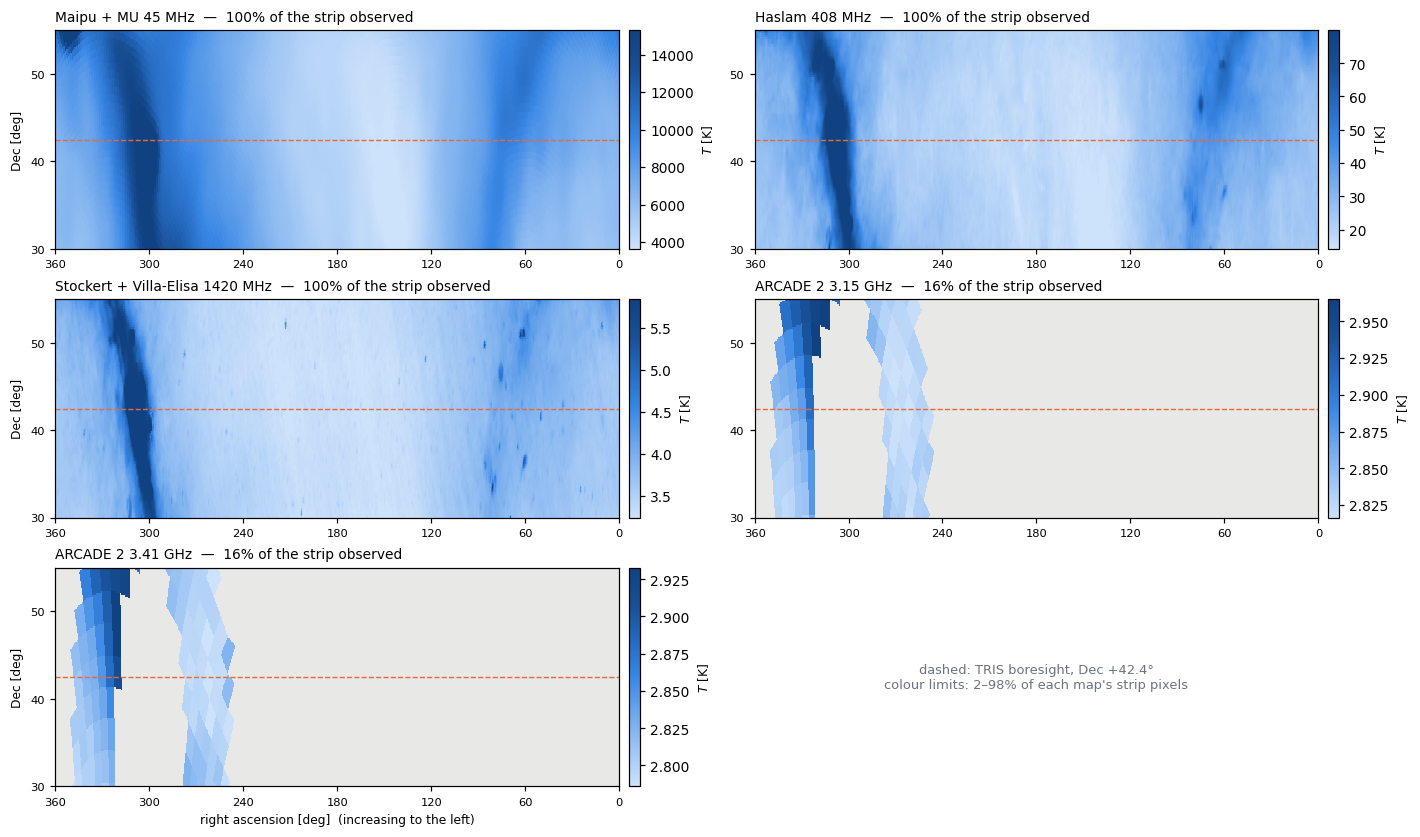

In [ ]:
# The TRIS strip, cut out of every map as a rectangular RA/Dec slice: the same plate-carrée
# view as the per-map cartview panels above, but sampled pixel by pixel at each RA/Dec,
# so latra really is declination, and drawn on axes that show RA and Dec.
STRIP_RA = np.linspace(360.0, 0.0, 1801)                 # left -> right: RA decreasing
STRIP_DEC = np.linspace(TRIS_STRIP_DEC[0], TRIS_STRIP_DEC[1], 126)

def strip_image(m):
    ra2d, dec2d = np.meshgrid(STRIP_RA, STRIP_DEC)
    theta, phi = np.radians(90.0 - dec2d).ravel(), np.radians(ra2d).ravel()
    frame = m["frame"] or "G"
    if frame != "C":
        theta, phi = hp.Rotator(coord=["C", frame])(theta, phi)   # RA/Dec -> map frame
    pix = hp.ang2pix(m["nside"], theta, phi)                       # nearest pixel, as cartview
    return m["sky"][pix].reshape(ra2d.shape)

slice_cmap = SEQ.copy()
slice_cmap.set_bad(MAP_KW["badcolor"])     # unobserved: the notebook's recessive grey
# SEQ paints values below vmin WHITE (healpy needs that for its page background). On a
# slice that turns the coldest 2% of sky into fake holes, so clip to the ramp's ends here.
slice_cmap.set_under(BLUE_RAMP[0])
slice_cmap.set_over(BLUE_RAMP[-1])
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(6.4 * N_COLS, 2.0 * n_rows),
                         squeeze=False, constrained_layout=True)
for ax, m in zip(axes.flat, MAPS):
    img = strip_image(m)
    seen = np.isfinite(img)
    lo, hi = (np.percentile(img[seen], [2, 98]) if seen.any() else (0.0, 1.0))
    im = ax.imshow(np.ma.masked_invalid(img), origin="lower", aspect="auto", cmap=slice_cmap,
                   vmin=lo, vmax=hi, interpolation="nearest",
                   extent=[STRIP_RA[0], STRIP_RA[-1], STRIP_DEC[0], STRIP_DEC[-1]])
    ax.axhline(TRIS_BORESIGHT_DEC, color=STRIP_COLOUR, lw=0.9, ls="--")
    ax.set_xticks(np.arange(360, -1, -60)); ax.set_yticks([30, 40, 50])
    ax.tick_params(labelsize=7.5)
    ax.set_title(f"{m['name']}  —  {100 * seen.mean():.0f}% of the strip observed",
                 fontsize=9, loc="left")
    unit = "$T$ [K]" if m["in_kelvin"] else f"[{m['unit'] or 'unit unknown'}]"
    fig.colorbar(im, ax=ax, pad=0.01, fraction=0.04).set_label(unit, fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("right ascension [deg]  (increasing to the left)", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Dec [deg]", fontsize=8)
for ax in axes.flat[len(MAPS):]:
    ax.axis("off")
    ax.text(0.5, 0.5, f"dashed: TRIS boresight, Dec +{TRIS_BORESIGHT_DEC:.1f}°\n"
            "colour limits: 2–98% of each map's strip pixels",
            ha="center", va="center", fontsize=8.5, color="#6b7280", transform=ax.transAxes)
plt.show()

### Frequencies, grids and beams

* **Beam nside.** Only TRIS has a beam that is a HEALPix map. limTOD builds it from the
  archive cuts at the map's nside, then up-samples it to `tris.nside_hires` (the `→`
  value). Every other survey publishes its beam as a FWHM only, so its beam nside and
  beam resolution are `—`.
* **Frame** is each map's own coordinate system, and which header keyword states it.
  ARCADE 2 uses `SKYCOORD`, which healpy does not read. The TRIS stage 1 maps store no
  frame at all: they are equatorial by construction.
* **Resolution.** "Res." is the HEALPix pixel size, `hp.nside2resol(nside)`, of that grid.
* **The TRIS rows** describe the stage 1 maps the rings turn into. The files in `res/` are
  the rings themselves.

In [5]:
def pixel_deg(nside):
    return hp.nside2resol(nside, arcmin=True) / 60.0

def fmt_deg(d):
    return f"{d * 60:.1f}′" if d < 1 else f"{d:.2f}°"

FRAME_NAME = {"G": "Galactic", "C": "Equatorial", "E": "Ecliptic"}

def frame_label(code, source):
    return f"{FRAME_NAME.get(code, '?')} ({source})" if code else "? (not stated)"

rows = [dict(freq=m["freq_mhz"], name=m["name"], beam_nside=None, nside=m["nside"],
             frame=frame_label(m["frame"], m["frame_src"]),
             fwhm=m["fwhm"], fwhm_src=m["fwhm_src"],
             note=m["external"] or "") for m in MAPS]

if TRIS_RINGS:
    beam_cut_files = sorted(RES.glob("TRIS_Beam_Profile*.txt"))
    if beam_cut_files:
        e_hpbw, h_hpbw = tris.read_tris_beam_cuts(beam_cut_files[0]).half_power_full_width_deg()
        tris_fwhm, tris_src = f"{e_hpbw:.2f}° (E) × {h_hpbw:.2f}° (H)", beam_cut_files[0].name
    else:
        tris_fwhm, tris_src = None, None
    tris_nside = int(config.require("tris.nside"))
    hires = int(config.require("tris.nside_hires"))
    for name, ring in TRIS_RINGS:
        nominal = re.search(r"(\d+)", name)          # the file's nominal label, e.g. 820
        label = nominal.group(1) if nominal else f"{ring.effective_frequency_mhz:.0f}"
        rows.append(dict(freq=ring.effective_frequency_mhz,
                         name=f"TRIS {label} MHz (stage 1 map)",
                         beam_nside=(tris_nside, hires), nside=tris_nside,
                         frame=frame_label("C", "by construction, not stored"), fwhm=tris_fwhm,
                         fwhm_src=tris_src, note=f"from {name}; nside = tris.nside"))
rows.sort(key=lambda r: (r["freq"] is None, r["freq"] or 0.0))

header = (f"{'freq [MHz]':>10}  {'map':<34}{'frame (from)':<40}{'beam nside':>11}{'map nside':>10}"
          f"{'beam res.':>11}{'beam width (FWHM)':>32}{'map res.':>10}   beam width from")
print(header)
print("-" * len(header))
for r in rows:
    freq = "?" if r["freq"] is None else f"{r['freq']:.1f}"
    beam_nside = "—" if r["beam_nside"] is None else f"{r['beam_nside'][0]} (→{r['beam_nside'][1]})"
    beam_res = "—" if r["beam_nside"] is None else fmt_deg(pixel_deg(r["beam_nside"][0]))
    print(f"{freq:>10}  {r['name']:<34}{r['frame']:<40}{beam_nside:>11}{r['nside']:>10}{beam_res:>11}"
          f"{r['fwhm'] or '?':>32}{fmt_deg(pixel_deg(r['nside'])):>10}   "
          f"{r['fwhm_src'] or '?'}")
notes = [(r["name"], r["note"]) for r in rows if r["note"]]
if notes:
    print("\nnot in the file itself:")
    for name, note in notes:
        print(f"  {name:<34} {note}")

freq [MHz]  map                               frame (from)                             beam nside map nside  beam res.               beam width (FWHM)  map res.   beam width from
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      45.0  Maipu + MU 45 MHz                 Galactic (header COORDSYS)                        —        64          — 4.6° × 2.4° (Maipu) / 3.6° (MU)     55.0′   external
     408.0  Haslam 408 MHz                    Galactic (header COORDSYS)                        —       512          —                             56′      6.9′   header BEAMSIZE
     600.5  TRIS 600 MHz (stage 1 map)        Equatorial (by construction, not stored)    8 (→16)         8      7.33°         19.15° (E) × 23.37° (H)     7.33°   TRIS_Beam_Profile.txt
     817.8  TRIS 820 MHz (stage 1 map)        Equatorial (by construction, not stored)    8 (→16)         

---
# 06 — The TRIS TOD each map predicts

Every map in `res/`, the ones section 05 discovered, is observed the way TRIS observed the
sky. limTOD's own simulator, `generate_TOD_sky`, sweeps the TRIS beam across each map and
returns the time-ordered data (TOD) that map predicts at each of the ring's 120 samples.
This is the same forward model section 01 used for GSM2008, applied to the real surveys.
Comparing the TODs puts every survey on the one footing TRIS itself provides.

**Stage 1's forward model, so the comparison is like-for-like with the map-maker:**

* **Geometry:** TRIS zenith geometry at the ring's own RA samples (Dec +42.4°, E plane
  rolled 7°). limTOD's simulator points the beam in the equatorial frame, so each map is
  rotated Galactic → equatorial first.
* **Grid:** the sky on the stage 1 grid, nside `tris.nside` = 8.
* **Beam:** built from the archive's E/H cuts at that nside, up-sampled to
  `tris.nside_hires`, with the horizon mask. This is the same beam stage 1 uses,
  including its 7.3° blocks (see the "how is the TRIS beam resolution decided"
  discussion). `TOD_NSIDE` below changes the grid in one place.

**Partial maps.** ARCADE 2, and the blank caps in Maipu and Stockert, are handled with two
simulator runs per map: one on the masked sky with the unobserved pixels at zero, and one
on the observed-fraction map. The ratio is the beam average over **observed** sky only,
and the second run is each sample's **coverage**: the fraction of the beam that landed on
observed sky. Samples with coverage below `MIN_COVERAGE` = 0.5, the same majority rule as
stage 2's weight floor, are drawn dotted and left out of the comparisons. The TRIS beam
is wider than ARCADE 2's observed ring, so ARCADE 2 never gets above about 65% coverage.
Its TODs are therefore **partial-beam** averages, usable only across the stretch of RA where
its ring crosses the TRIS strip.

**Units, for the comparisons.** Each TOD is first plotted in its map's own temperature.
To compare across frequencies, the CMB is removed in Rayleigh-Jeans terms:
$T_A(T) - T_A(T_0)$ for ARCADE 2, which is thermodynamic, and $T - T_{\mathrm{CMB,RJ}}(\nu)$
for the others. The TRIS rings are the real data at 600.5 and 817.8 MHz, and they are
drawn as the reference.

In [6]:
from limTOD import generate_TOD_sky

TOD_NSIDE = int(config.require("tris.nside"))          # stage 1's grid: 8
TOD_NSIDE_HIRES = int(config.require("tris.nside_hires"))
DEGRADE_FIRST = 64        # bring big maps to this nside before rotating (speed only)
# A sample is compared only if at least half the beam fell on observed sky: the same
# majority rule as stage 2's weight floor.  ARCADE 2 never exceeds ~0.65 -- the TRIS beam
# is wider than its observed ring -- so a stricter cut would leave it with nothing.
MIN_COVERAGE = 0.5

ref_name, REF_RING = TRIS_RINGS[0]                     # both rings share one RA grid
GEOM = tris.tris_zenith_geometry(REF_RING.ra_deg)
TOD_RA = np.asarray(REF_RING.ra_deg)
BEAM_TOD = tris.tris_cut_beam_map(tris.read_tris_beam_cuts(RES / "TRIS_Beam_Profile.txt"),
                                  nside=TOD_NSIDE, normalization="peak")
HORIZON_TOD = tris.tris_horizon_mask(TOD_NSIDE)

def observe(sky_eq):
    # One limTOD sweep of the TRIS beam over an equatorial map.
    return np.asarray(generate_TOD_sky(
        BEAM_TOD, sky_eq, GEOM.lst_deg, GEOM.latitude_deg, GEOM.azimuth_deg,
        GEOM.elevation_deg, GEOM.selfrot_deg, nside_hires=TOD_NSIDE_HIRES,
        normalize_beam=True, horizontal_mask=HORIZON_TOD))

def equatorial_pair(m):
    # (sum of observed values, observed fraction) per TOD_NSIDE pixel, in equatorial.
    observed = np.isfinite(m["sky"])
    filled, weight = np.where(observed, m["sky"], 0.0), observed.astype(float)
    if m["nside"] > DEGRADE_FIRST:                      # mean over children, zeros included
        filled, weight = hp.ud_grade(filled, DEGRADE_FIRST), hp.ud_grade(weight, DEGRADE_FIRST)
    frame = m["frame"] or "G"
    if frame != "C":
        rot = hp.Rotator(coord=[frame, "C"])
        filled, weight = rot.rotate_map_pixel(filled), rot.rotate_map_pixel(weight)
    return hp.ud_grade(filled, TOD_NSIDE), hp.ud_grade(weight, TOD_NSIDE)

def rj_excess(t_k, m):
    # CMB-subtracted Rayleigh-Jeans temperature at the map's own frequency.
    nu = m["freq_mhz"]
    note = EXTERNAL_METADATA.get(m["file"], {}).get("source", "")
    if "thermodynamic" in note.lower():                          # ARCADE 2 (LAMBDA)
        x = lambda t: (6.62607015e-34 * nu * 1e6) / (1.380649e-23 * t)
        t_a = lambda t: t * x(t) / np.expm1(x(t))
        return t_a(t_k) - t_a(2.72548)
    return t_k - tris.cmb_monopole_rj_k(nu)

TODS = {}
for m in MAPS:
    if not m["in_kelvin"] or m["freq_mhz"] is None:
        print(f"{m['name']}: unit or frequency unknown -- simulated but not compared")
    filled, weight = equatorial_pair(m)
    summed, coverage = observe(filled), observe(weight)
    with np.errstate(invalid="ignore", divide="ignore"):
        tod = np.where(coverage > 0, summed / coverage, np.nan)
    TODS[m["name"]] = dict(map=m, tod=tod, coverage=coverage,
                           good=coverage >= MIN_COVERAGE)
    print(f"{m['name']:<34} coverage {coverage.min():.3f}–{coverage.max():.3f}; "
          f"{int((coverage >= MIN_COVERAGE).sum()):3d}/{coverage.size} samples ≥ {MIN_COVERAGE}")

Maipu + MU 45 MHz                  coverage 0.988–0.997; 120/120 samples ≥ 0.5


Haslam 408 MHz                     coverage 1.000–1.000; 120/120 samples ≥ 0.5


Stockert + Villa-Elisa 1420 MHz    coverage 0.999–1.000; 120/120 samples ≥ 0.5


ARCADE 2 3.15 GHz                  coverage -0.005–0.617;  14/120 samples ≥ 0.5


ARCADE 2 3.41 GHz                  coverage -0.006–0.630;  16/120 samples ≥ 0.5


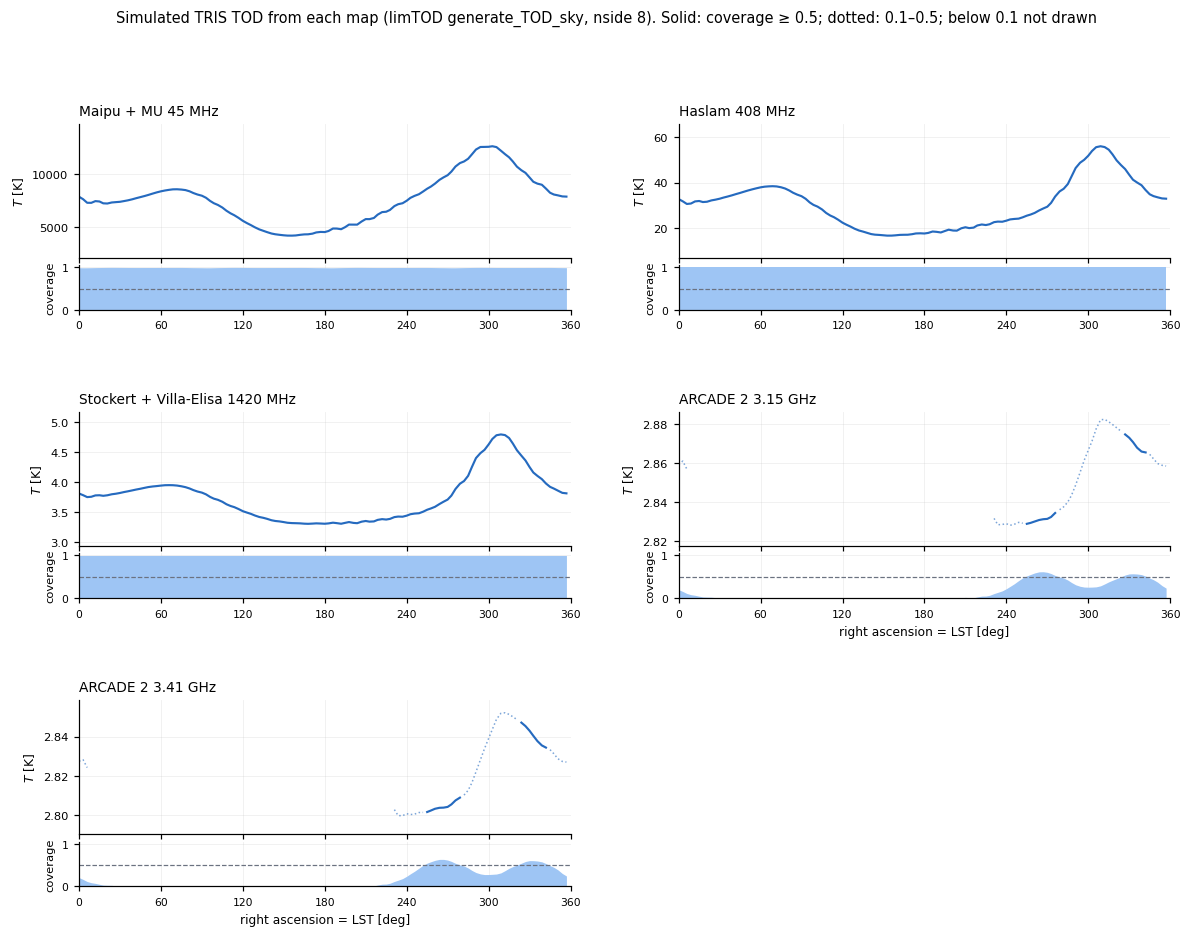

In [7]:
# One panel per map: the TOD in the map's own temperature, with the coverage underneath.
N_COLS = 2
n_rows = int(np.ceil(len(TODS) / N_COLS))
fig = plt.figure(figsize=(6.4 * N_COLS, 3.0 * n_rows))
outer = fig.add_gridspec(n_rows, N_COLS, hspace=0.55, wspace=0.22)
for k, (name, d) in enumerate(TODS.items()):
    inner = outer[k // N_COLS, k % N_COLS].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax, axc = fig.add_subplot(inner[0]), fig.add_subplot(inner[1])
    good = d["good"]
    # Below ~10% coverage the ratio divides by almost nothing and is noise; don't draw it.
    faint = ~good & (d["coverage"] >= 0.1)
    ax.plot(TOD_RA, np.where(good, d["tod"], np.nan), "-", color="#256abf", lw=1.4)
    ax.plot(TOD_RA, np.where(faint, d["tod"], np.nan), ":", color="#256abf", lw=1.0, alpha=0.6)
    if good.any():                                  # scale to what can be compared
        lo_t, hi_t = np.nanmin(d["tod"][good]), np.nanmax(d["tod"][good])
        pad = 0.25 * (hi_t - lo_t) if hi_t > lo_t else 0.05 * abs(hi_t)
        ax.set_ylim(lo_t - pad, hi_t + pad)
    unit = "$T$ [K]" if d["map"]["in_kelvin"] else f"[{d['map']['unit'] or '?'}]"
    ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f"{name}", fontsize=9, loc="left")
    ax.tick_params(labelbottom=False, labelsize=7.5)
    axc.fill_between(TOD_RA, 0, d["coverage"], color="#9ec5f4", lw=0)
    axc.axhline(MIN_COVERAGE, color="#6b7280", lw=0.8, ls="--")
    axc.set_ylim(0, 1.05); axc.set_ylabel("coverage", fontsize=7.5)
    axc.tick_params(labelsize=7)
    for a in (ax, axc):
        a.set_xlim(0, 360); a.set_xticks(np.arange(0, 361, 60))
        a.grid(alpha=0.18, lw=0.6); a.set_axisbelow(True)
        for side in ("top", "right"):
            a.spines[side].set_visible(False)
    if k // N_COLS == n_rows - 1 or k + N_COLS >= len(TODS):
        axc.set_xlabel("right ascension = LST [deg]", fontsize=8)
fig.suptitle(f"Simulated TRIS TOD from each map (limTOD generate_TOD_sky, nside {TOD_NSIDE}). "
             f"Solid: coverage ≥ {MIN_COVERAGE}; dotted: 0.1–{MIN_COVERAGE}; below 0.1 not drawn",
             fontsize=9.5, y=0.995)
plt.show()

### Against each other, and against what TRIS actually measured

**Left: shape.** Each CMB-subtracted TOD is divided by its own mean over the samples every
map covers, so amplitude and frequency drop out and only the RA structure remains. Where
the curves agree, the surveys see the same sky through the TRIS beam. Where they split,
one survey's structure, zero level or scanning differs from the rest.

**Right: spectral index against the TRIS 600 MHz ring.** For each sample,

$$\beta(t) = \frac{\ln\!\left[T_\mathrm{map}(t)/T_\mathrm{TRIS\,600}(t)\right]}{\ln\left(\nu_\mathrm{map}/600.5\ \mathrm{MHz}\right)}$$

with both temperatures CMB-subtracted. A survey consistent with TRIS and with synchrotron
gives a flat line near −2.5 to −3.0. A drift with RA points to a zero-level or gain
difference, because a constant offset matters most where the sky is faint. TRIS 820 is
included as a TRIS-only check.

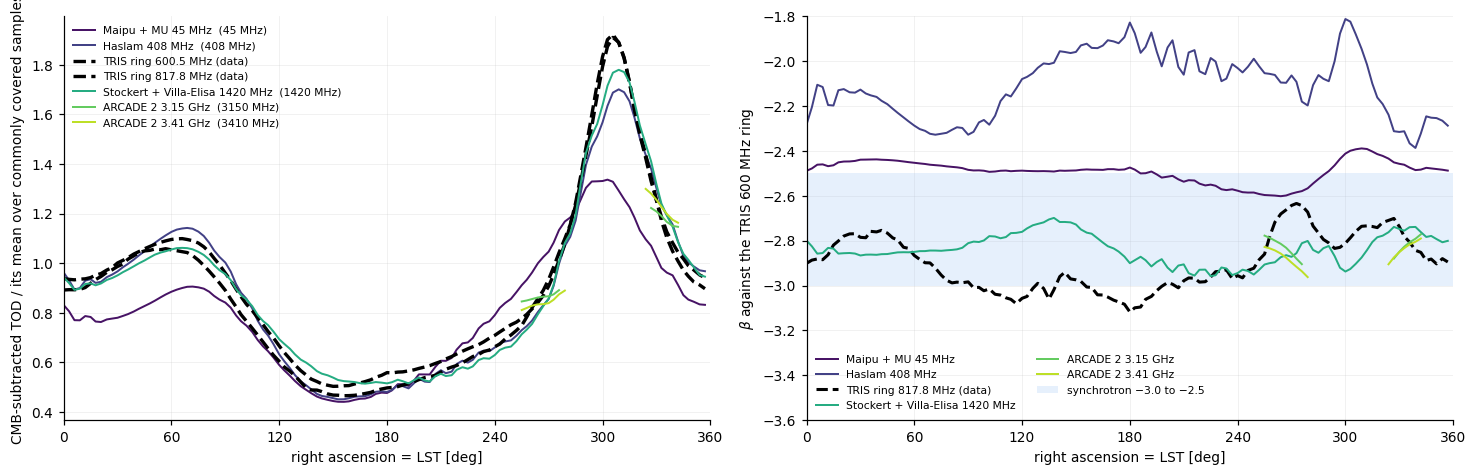

TOD                                       ν [MHz]      mean       min       max  peak RA   β vs TRIS600 (median, 16–84%)
Maipu + MU 45 MHz                            45.0  7591.123  4173.317 12643.051    302.8            -2.48 (-2.55, -2.45)
Haslam 408 MHz                              408.0    27.592    14.097    53.112    309.0            -2.09 (-2.28, -1.95)
TRIS ring 600.5 MHz (data)                  600.5    12.139     6.679    25.482    305.8                               —
TRIS ring 817.8 MHz (data)                  817.8     5.008     2.651    10.868    305.8            -2.91 (-3.02, -2.76)
Stockert + Villa-Elisa 1420 MHz            1420.0     1.055     0.609     2.108    309.0            -2.85 (-2.91, -2.76)
ARCADE 2 3.15 GHz                          3150.0     0.122     0.103     0.149    327.0            -2.82 (-2.88, -2.79)
ARCADE 2 3.41 GHz                          3410.0     0.095     0.076     0.122    324.0            -2.85 (-2.91, -2.82)

Temperatures are CMB-subtracted

In [8]:
REF600 = next(r for n, r in TRIS_RINGS if "600" in n)
ref600_ex = np.asarray(REF600.temperature_k) - tris.cmb_monopole_rj_k(REF600.effective_frequency_mhz)
nu600 = REF600.effective_frequency_mhz

compared = {n: d for n, d in TODS.items() if d["map"]["in_kelvin"] and d["map"]["freq_mhz"]}
common = np.all([d["good"] for d in compared.values()], axis=0)

series = {}                                   # name -> (frequency, CMB-subtracted TOD, usable)
for name, d in compared.items():
    series[name] = (d["map"]["freq_mhz"], rj_excess(d["tod"], d["map"]), d["good"])
for name, ring in TRIS_RINGS:                 # the real TRIS data, as reference
    ex = np.asarray(ring.temperature_k) - tris.cmb_monopole_rj_k(ring.effective_frequency_mhz)
    series[f"TRIS ring {ring.effective_frequency_mhz:.1f} MHz (data)"] = (
        ring.effective_frequency_mhz, ex, np.ones(ex.size, bool))

order = sorted(series, key=lambda n: series[n][0])
palette = plt.get_cmap("viridis")(np.linspace(0.05, 0.9, len(order)))
colour = dict(zip(order, palette))

fig, (ax_s, ax_b) = plt.subplots(1, 2, figsize=(13.5, 4.4))
norm_on = common if common.any() else np.ones(TOD_RA.size, bool)
for name in order:
    nu, ex, ok = series[name]
    is_data = "(data)" in name
    shape = ex / np.mean(ex[norm_on])
    ax_s.plot(TOD_RA, np.where(ok, shape, np.nan), "-" if not is_data else "--",
              lw=2.2 if is_data else 1.3, color="k" if is_data else colour[name],
              label=f"{name}" + ("" if is_data else f"  ({nu:g} MHz)"))
    if "600" in name and is_data:
        continue
    with np.errstate(invalid="ignore", divide="ignore"):
        beta = np.log(ex / ref600_ex) / np.log(nu / nu600)
    ax_b.plot(TOD_RA, np.where(ok & (ex > 0) & (ref600_ex > 0), beta, np.nan),
              "--" if is_data else "-", lw=2.0 if is_data else 1.3,
              color="k" if is_data else colour[name], label=name)
ax_b.axhspan(-3.0, -2.5, color="#9ec5f4", alpha=0.25, lw=0, label="synchrotron −3.0 to −2.5")
ax_s.set_ylabel("CMB-subtracted TOD / its mean over commonly covered samples")
ax_b.set_ylabel(r"$\beta$ against the TRIS 600 MHz ring")
ax_b.set_ylim(-3.6, -1.8)
for ax in (ax_s, ax_b):
    ax.set_xlabel("right ascension = LST [deg]")
    ax.set_xlim(0, 360); ax.set_xticks(np.arange(0, 361, 60))
    ax.grid(alpha=0.18, lw=0.6); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
ax_s.legend(fontsize=7, frameon=False, loc="upper left")
ax_b.legend(fontsize=7, frameon=False, loc="lower left", ncol=2)
fig.tight_layout()
plt.show()

print(f"{'TOD':<40}{'ν [MHz]':>9}{'mean':>10}{'min':>10}{'max':>10}{'peak RA':>9}"
      f"{'β vs TRIS600 (median, 16–84%)':>32}")
for name in order:
    nu, ex, ok = series[name]
    t = ex[ok]
    if t.size == 0:
        print(f"{name:<40}{nu:9.1f}   no sample with coverage ≥ {MIN_COVERAGE}")
        continue
    with np.errstate(invalid="ignore", divide="ignore"):
        beta = np.log(ex / ref600_ex) / np.log(nu / nu600)
    b = beta[ok & np.isfinite(beta)]
    btxt = "—" if ("600" in name and "(data)" in name) or b.size == 0 else \
        f"{np.median(b):+.2f} ({np.percentile(b, 16):+.2f}, {np.percentile(b, 84):+.2f})"
    print(f"{name:<40}{nu:9.1f}{t.mean():10.3f}{t.min():10.3f}{t.max():10.3f}"
          f"{TOD_RA[ok][np.argmax(t)]:9.1f}{btxt:>32}")
print("\nTemperatures are CMB-subtracted, in K (RJ), over each TOD's usable samples.")
print(f"The shape panel normalises every curve over the {int(common.sum())} samples that ALL "
      f"maps cover (RA {TOD_RA[common].min():.0f}–{TOD_RA[common].max():.0f}°)."
      if common.any() else "No sample is covered by every map; shapes use all samples.")